<a href="https://colab.research.google.com/github/Ahbar1999/mtp-pimsimulator/blob/main/pimsimulator_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Code Summary**


*   In the (wear count and address translation) arrays and indices of the arrays are logical array ids   
*   For intra crossbar wear levelling, row swapping is being implemented as given in the TIME paper, DRCTL implements intra crossbar wear levelling by doing continuous shifting of row, columns which does not take into account the dynamic ageing
*   For inter crossbar wear levelling, TIWL's approach is being implemented
*   Currently the writes are being accumulated per xbar, we need to accumulate writes per cell

Implmentation References:
*   ODLPIM: https://past.date-conference.com/proceedings-archive/2023/DATA/357.pdf
*   DRCTL:  https://ieeexplore.ieee.org/document/10764631
*   TIME:   https://dl.acm.org/doi/10.1145/3195970.3196071

**TO-DO**

*   Find the statistic used in the paper for determining performance of intra crossbar wear levelling, use it find results
*   Currently only the gradient weights i.e. memory thats being written to, is monitored, we dont know how the other memory access i.e reads are taking place, also when you change address mappings, how are the memory accesses dependent on changed mappings get affected ?



**Learnings/Experiments**

*   Row swapping intervals/ min-max ratio thresholds to swap:
      Using smaller min-max ratio and smaller swapping intervals did not result in smaller max-count for rows because of ???
*        



PROBLEMS:
  1- There's a discrepency between row write counters and crossbar write counters ; fix it

  Answer:
      Why the "Contradiction" happened (Rows vs. Xbars)
      Row Plot: Visualizes row_write_counts. This is an accumulative array that never resets. It captured the writes at Physical 50-99 and the writes at Physical 0-49. Because the Intra-block remapping (row_mappings) is working, it spread those writes across all rows within those blocks. To your eye, it looked "fully colored" because the rows were active in the active blocks.
      
      Crossbar Plot: Visualizes twc_counters. This showed the total wear per block. Because of the Double Registration, you had massive unused space (Physical 100-511). The imshow function likely scaled the colors such that the active blocks looked like "points" in a sea of black zeros.

In [1]:
import numpy as np
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from collections import defaultdict

In [2]:
class PIMSimulator:
    def __init__(self,
                 num_crossbars=1024,
                 crossbar_size=(128, 128),
                 bits_per_cell=1,
                 weight_bits=8,
                 wear_levelling_enabled=True,
                 intra_xbar_wear_levelling_enabled=True,
                 slc_bits=1,
                 mlc_bits=4,
                 slc_mlc_ratio=0.1):
        """Config params"""
        self.num_crossbars = num_crossbars
        self.crossbar_rows, self.crossbar_cols = crossbar_size
        self.bits_per_cell = bits_per_cell  # bit resolution of each reram cell(regardless of whether cell is slc or mlc)
        # (quantization)bits per weight
        self.weight_bits = weight_bits
        self.wear_levelling_enabled = wear_levelling_enabled
        self.intra_xbar_wear_levelling_enabled = intra_xbar_wear_levelling_enabled

        # Calculate how many weights fit in one crossbar
        self.cells_per_crossbar = self.crossbar_rows * self.crossbar_cols
        self.weights_per_crossbar = self.cells_per_crossbar // self.weight_bits

        # interval write counters for each crossbar
        self.iwc_counters = np.zeros(num_crossbars, dtype=np.uint32)
        # total write counters for each crossbar
        self.twc_counters = np.zeros(num_crossbars, dtype=np.uint64)

        # addressing granularity is a crossbar
        # LAID -> PAID: initial mapping is i -> i
        self.access_count = 0                   # xbar memory accesses
        self.access_count_for_rows = 0
        self.remapping_interval = 1000

        self.tensor_registry = {}           # tensor_name -> segment_list
        # the following map should be changed to xbar_base_addr -> xbar_object
        # the crossbar object will have an address field
        self.laid_to_paid_map = {}          # logical to physical xbar ids
        self.next_laid = 0                  # next free LAID(that maps to physical id)
        self.next_physical_crossbar = 0     # next free PAID(of the actual crossbar)

        # row mapping code
        # write count 2D array for xbar * rows_per_xbar
        # [physical xbar id][physical row id] => logical row id: Wrong mapping
        # [physical xbar id][logical row id] => physical row id

        self.row_write_counts = np.zeros((num_crossbars, self.crossbar_rows), dtype=np.int64)
        self.row_mappings = [list(range(self.crossbar_rows)) for _ in range(num_crossbars)]

        # row max / min
        self.row_swap_threshold = 2.0
        # swap rows every row_swap_interval writes
        self.row_swap_interval = 10000
        self.total_row_swaps =0

        # param update frequency counters
        self.param_update_counter: dict['str', dict['str', int]] = {}
        # gradient magnitudes
        self.grad_updates = {}

        # [NEW] slc/mlc config
        self.slc_bits = slc_bits
        self.mlc_bits = mlc_bits
        self.num_slc_xbars = int(num_crossbars * slc_mlc_ratio)
        self.num_mlc_xbars = num_crossbars - self.num_slc_xbars
        self.actual_xbars_used = 0

        # Physical Pools
        self.slc_pool = list(range(0, self.num_slc_xbars))
        self.mlc_pool = list(range(self.num_slc_xbars, num_crossbars))

        # method to use to log memory accesses
        self.logger = None

        print(f"Crossbar config: {crossbar_size}, {self.weights_per_crossbar} weights per crossbar")
        if not self.wear_levelling_enabled:
          print("Wear levelling disabled")

    def register_model(self, model):
        """Build collision-free mapping for all tensors once before running the model"""
        for name, param in model.named_parameters():
            # generate mapping for trainable parameters
            if param.requires_grad:
                # segment are basically individual xbar mappings for the whole tensor
                segments = self._partition_tensor(name, param)
                self.tensor_registry[name] = segments

    def _partition_tensor(self, tensor_name, tensor):
        """Distribute tensor weights to xbars"""
        tensor_size = tensor.numel()
        crossbars_needed = math.ceil(tensor_size / self.weights_per_crossbar)
        # add to the count of total xbars
        self.actual_xbars_used += crossbars_needed
        # print(f"Number of Crossbars needed to deploy {tensor_name}: {crossbars_needed}")

        segments = []
        remaining_elements = tensor_size

        for i in range(crossbars_needed):
            laid = self.next_laid
            if self.next_physical_crossbar >= self.num_crossbars:
                raise ValueError(f"Not enough crossbars for tensor {tensor_name}, exiting program.")

            paid = self.next_physical_crossbar
            elements = min(remaining_elements, self.weights_per_crossbar)

            '''
              removed the following field from segments object
              'logical_offset': tensor_size - remaining_elements # not required; what even is it ?
            '''
            segments.append({
                'laid': laid,
                'paid': paid,
                'elements': elements,
            })

            # Initial i -> i mapping
            self.laid_to_paid_map[laid] = paid

            self.next_laid += 1
            self.next_physical_crossbar += 1
            remaining_elements -= elements

        return segments

    def log_memory_access(self, tensor_name, k_swaps=-1, is_write=True):
        """Accurate logging considering tensor size and crossbar capacity"""
        if tensor_name not in self.tensor_registry:
            return

        if tensor_name not in self.param_update_counter:
            self.param_update_counter[tensor_name] = {}

        if not is_write:
          if 'read' not in self.param_update_counter[tensor_name]:
            self.param_update_counter[tensor_name]['read'] = 0
          self.param_update_counter[tensor_name]['read'] += 1
        else:
          if 'write' not in self.param_update_counter[tensor_name]:
            self.param_update_counter[tensor_name]['write'] = 0
          self.param_update_counter[tensor_name]['write'] += 1

        for segment in self.tensor_registry[tensor_name]:
            laid = segment['laid']
            current_paid = self.laid_to_paid_map[laid]  # address translation
            elements = segment['elements'] # an element is a single param

            writes_per_element = self.weight_bits // self.bits_per_cell
            total_writes = elements * writes_per_element

            # record interval write count for current xbar
            # self.iwc_counters[current_paid] += total_writes
            # if segment['mode'] == 'SLC':
            self.iwc_counters[laid] += total_writes
            self._log_row_level_writes(laid, elements, total_writes)

        self.access_count += 1
        # this could be problematic
        self.access_count_for_rows += 1

        if self.access_count % self.remapping_interval == 0:
            self.perform_remapping(k_swaps)

        if self.access_count_for_rows % self.remapping_interval == 0:
            self.perform_row_remapping()

    def _log_row_level_writes(self, crossbar_laid, elements, total_writes):
        weights_per_row = self.crossbar_cols * (self.bits_per_cell // self.weight_bits)
        if weights_per_row <= 0:
            weights_per_row = self.crossbar_cols // 8  # Fallback: assume 8-bit weights

        rows_affected = math.ceil(elements / weights_per_row)
        writes_per_row = total_writes // rows_affected if rows_affected > 0 else total_writes

        for logical_row in range(min(rows_affected, self.crossbar_rows)):
            physical_xbar = self.laid_to_paid_map[crossbar_laid]
            physical_row = self.row_mappings[physical_xbar][logical_row]

            # assert(physical_xbar < 128 and physical_row < 128)
            self.row_write_counts[physical_xbar][physical_row] += writes_per_row

    # this has to be performed within each xbar
    def perform_row_remapping(self):
        if not self.wear_levelling_enabled or not self.intra_xbar_wear_levelling_enabled:
          return

        """Perform new swapping within crossbars to balance row-level wear"""
        """Swaps 2 highest and lowest utilized rows in xbars"""
        # print("Performing Row Remapping...")

        # crossbar_id <-> laid
        for crossbar_id in range(self.num_crossbars):
          row_counts = self.row_write_counts[crossbar_id]

          if np.sum(row_counts) == 0:
            continue

          max_wear_physical = np.max(row_counts)  # maximum write count
          min_wear_physical = np.min(row_counts)  # minimum write count

          if min_wear_physical == 0 or (max_wear_physical / min_wear_physical) < self.row_swap_threshold:
            continue

          # get logical id of the rows with min, max write counts
          max_logical = np.argmax(row_counts)
          min_logical = np.argmin(row_counts)

          # # swap physical ids of the min/max rows
          # self.row_mappings[crossbar_id][max_logical] = self.row_mappings[crossbar_id][min_logical]
          # self.row_mappings[crossbar_id][min_logical] = self.row_mappings[crossbar_id][max_logical]

          phys_max = self.row_mappings[crossbar_id][max_logical]
          phys_min = self.row_mappings[crossbar_id][min_logical]

          # Swap min/max physical ids
          self.row_mappings[crossbar_id][max_logical] = phys_min
          self.row_mappings[crossbar_id][min_logical] = phys_max

          self.total_row_swaps += 1
          # print("row swapped")
          # # exit(0)

          # Optional: Log the swap
          if self.access_count % (self.row_swap_interval * 10) == 0:  # Log occasionally
            print(f"Row swap in crossbar {crossbar_id}: "
                  f"logical {max_logical}→physical {min_wear_physical}, "
                  f"logical {min_logical}→physical {max_wear_physical} "
                  f"(wear ratio: {max_wear_physical/min_wear_physical:.2f})")

    def perform_remapping(self, k=-1):
        # print("Updating write counters")
        # Update Total Wear Count (TWC)
        for laid, iwc in enumerate(self.iwc_counters):
            paid = self.laid_to_paid_map.get(laid, laid)
            self.twc_counters[paid] += iwc

        if not self.wear_levelling_enabled:
            # print("wear levelling has been disabled!")
            return

        # print("Performing Remapping...")
        # Sort crossbars by wear level (TWC)
        wear_sorted_crossbars = sorted(enumerate(self.twc_counters), key=lambda x: x[1])

        # Sort logical crossbars by hotness (recent writes)
        hotness_sorted = sorted(enumerate(self.iwc_counters), key=lambda x: x[1], reverse=True)

        # Rebuild mapping: hottest logical → coolest physical
        new_mapping = self.laid_to_paid_map.copy()
        # (hot laid, hotness value)
        cap = int(len(wear_sorted_crossbars) * (k / 100.0))
        # if k != -1:
        #   print(f"remapping top {k}% xbars")
        # else:
        #   print("remapping all xbars")

        for i, (hot_laid, _) in enumerate(hotness_sorted):
            if i != -1 and i >= cap:
              # restrict remapping to only top k%
              break

            cool_paid, _ = wear_sorted_crossbars[i]  # Least worn physical crossbar
            new_mapping[hot_laid] = cool_paid

        self.laid_to_paid_map = new_mapping
        # reset counters
        self.iwc_counters.fill(0)

    def get_crossbar_utilization_stats(self):
        """Analyze crossbar utilization patterns"""
        stats = {
            'total_crossbars': self.num_crossbars,
            'weights_per_crossbar': self.weights_per_crossbar,
            'active_crossbars': np.count_nonzero(self.iwc_counters),
            'avg_wear': np.mean(self.twc_counters),
            'max_wear': np.max(self.twc_counters),
            'wear_imbalance': np.max(self.twc_counters) / (np.min(self.twc_counters) + 1)
        }
        return stats

    def get_row_wear_statistics(self):
      """
      Row-level wear statistics after considering intra-crossbar row swapping.
      Also returns crossbar-level stats derived from row data and reduction metrics.
      Relies on:
        - self.row_write_counts: shape (num_crossbars, crossbar_rows), physical rows
        - self.row_mappings: logical->physical mapping (not needed to read counts since counts are stored on physical rows)
        - self._total_row_swaps: optional counter (defaults to 0 if absent)
      """
      wear_rows = self.row_write_counts  # shape (C, R), physical rows
      row_sums_per_xbar = wear_rows.sum(axis=1)
      active_xbar_mask = row_sums_per_xbar > 0
      active_rows = wear_rows[active_xbar_mask]

      if active_rows.size == 0:
          return {
              'max_row_wear': 0,
              'min_row_wear': 0,
              'avg_row_wear': 0.0,
              'row_wear_imbalance': 1.0,
              'active_crossbars': 0,
              'total_row_swaps': int(getattr(self, 'total_row_swaps', 0)),
              # Aggregates per crossbar from row totals
              'max_xbar_wear_from_rows': 0,
              'min_xbar_wear_from_rows': 0,
              'avg_xbar_wear_from_rows': 0.0,
              'xbar_wear_imbalance_from_rows': 1.0
          }

      flat = active_rows.flatten()
      nonzero = flat[flat > 0]
      max_row = int(flat.max())
      min_row_active = int(nonzero.min()) if nonzero.size > 0 else 0
      avg_row = float(nonzero.mean()) if nonzero.size > 0 else 0.0
      row_imbalance = (max_row / min_row_active) if min_row_active > 0 else 1.0

      xbar_totals = active_rows.sum(axis=1)
      max_xbar = int(xbar_totals.max())
      min_xbar_active = int(xbar_totals[xbar_totals > 0].min()) if np.any(xbar_totals > 0) else 0
      avg_xbar = float(xbar_totals.mean()) if xbar_totals.size > 0 else 0.0
      xbar_imbalance = (max_xbar / min_xbar_active) if min_xbar_active > 0 else 1.0


      return {
          'max_row_wear': max_row,
          'min_row_wear': min_row_active,
          'avg_row_wear': avg_row,
          'row_wear_imbalance': row_imbalance,
          'active_crossbars': int(active_xbar_mask.sum()),
          'total_row_swaps': int(getattr(self, 'total_row_swaps', 0)),
          'max_xbar_wear_from_rows': max_xbar,
          'min_xbar_wear_from_rows': min_xbar_active,
          'avg_xbar_wear_from_rows': avg_xbar,
          'xbar_wear_imbalance_from_rows': xbar_imbalance
      }

    def _get_capacity(self, bits_per_cell):
      cells_per_xbar = self.crossbar_rows * self.crossbar_cols
      # How many weights fit depends on cell precision
      return (cells_per_xbar * bits_per_cell) // self.weight_bits

    def redistribute_tensors_by_magnitude(self, model, k_percent=10):
      """
      Runs once after initial epochs.
      Wipes existing registry and re-maps based on current weight magnitudes.
      """
      self.tensor_registry = {}
      self.laid_to_paid_map = {}
      self.next_laid = 0
      current_slc_idx = 0
      current_mlc_idx = 0
      # reset used xbars count because partitioning is enabled so we will consider the new count
      self.actual_xbars_used = 0
      print(f"Redistributing model: Top {k_percent}% to SLC ({self.slc_bits}-bit), rest to MLC ({self.mlc_bits}-bit)")

      for name, param in model.named_parameters():
          if not param.requires_grad:
            continue

          w = param.data.abs().view(-1)
          num_elements = w.size(0)

          # 1. Determine Threshold
          k_elements = int(num_elements * (k_percent / 100.0))
          if k_elements > 0:
              threshold = torch.kthvalue(w, num_elements - k_elements + 1).values.item()
          else:
              threshold = float('inf')

          # 2. Partition into SLC and MLC counts
          slc_elements = (w >= threshold).sum().item()
          mlc_elements = num_elements - slc_elements

          segments = []

          # 3. Map SLC Segments
          segments.extend(self._allocate_segments(slc_elements, mode='SLC', start_pool_idx=current_slc_idx))
          current_slc_idx += math.ceil(slc_elements / self._get_capacity(self.slc_bits))

          # 4. Map MLC Segments
          segments.extend(self._allocate_segments(mlc_elements, mode='MLC', start_pool_idx=current_mlc_idx))
          current_mlc_idx += math.ceil(mlc_elements / self._get_capacity(self.mlc_bits))

          self.tensor_registry[name] = segments

      self.actual_xbars_used = current_slc_idx + current_mlc_idx
      print(f"Mapping complete. SLC Xbars used: {current_slc_idx}/{self.num_slc_xbars}")

    def _allocate_segments(self, count, mode, start_pool_idx):
        segments = []
        bits = self.slc_bits if mode == 'SLC' else self.mlc_bits
        pool = self.slc_pool if mode == 'SLC' else self.mlc_pool
        capacity = self._get_capacity(bits)

        remaining = count
        local_idx = start_pool_idx

        while remaining > 0:
            if local_idx >= len(pool):
                raise ValueError(f"Out of {mode} crossbars!")

            elements_in_this_xbar = min(remaining, capacity)
            laid = self.next_laid
            paid = pool[local_idx]

            segments.append({
                'laid': laid,
                'paid': paid,
                'elements': elements_in_this_xbar,
                'bits_per_cell': bits,
                'mode': mode
            })

            self.laid_to_paid_map[laid] = paid
            self.next_laid += 1
            local_idx += 1
            remaining -= elements_in_this_xbar

        return segments

    def log_memory_access_v2(self, tensor_name, k_swaps=-1, is_write=True):
      if tensor_name not in self.tensor_registry:
        return

      for segment in self.tensor_registry[tensor_name]:
          laid = segment['laid']
          paid = self.laid_to_paid_map[laid]

          # Weight bits / bits_per_cell = pulses needed per weight
          pulses_per_element = self.weight_bits / segment['bits_per_cell']
          total_writes = int(segment['elements'] * pulses_per_element)

          if segment['mode'] == 'SLC':
            self.iwc_counters[laid] += total_writes
            # self.twc_counters[paid] += total_writes # Simplification for total wear
          ''''
          # Log row-level wear
          weights_per_row = (self.crossbar_cols * segment['bits_per_cell']) // self.weight_bits
          rows_affected = math.ceil(segment['elements'] / max(1, weights_per_row))
          writes_per_row = total_writes // max(1, rows_affected)

          self.access_count += 1
          self._log_row_level_writes(laid, segment['elements'], total_writes)
          # for row_idx in range(min(rows_affected, self.crossbar_rows)):
          #     self.row_write_counts[paid][row_idx] += writes_per_row
          '''

      self.access_count += 1
      if self.access_count % self.remapping_interval == 0:
          self.perform_remapping(k_swaps)
      '''
      if self.access_count_for_rows % self.remapping_interval == 0:
          self.perform_row_remapping()
      '''



In [3]:
class PIMTrainingHook:
    def __init__(self, pim_simulator, k_swaps=-1):
        self.pim_sim = pim_simulator
        self.hooks = []
        self.model_params = {} # To store model parameters by name
        self.k_swaps= k_swaps

    def forward_hook(self, module, input, output, name):
        """Log forward pass memory accesses"""
        tensor_name = f"{name}.weight"

        # self.pim_sim.log_memory_access(tensor_name, k_swaps=self.k_swaps, is_write=False)
        if not self.pim_sim.logger:
          raise ValueError("logger not set")

        self.pim_sim.logger(tensor_name, k_swaps=self.k_swaps, is_write=True)

    def backward_hook(self, grad, name):
      tensor_name = f"{name}.weight"

      # log param update magnitude
      if grad is not None:
        norm = torch.norm(grad).item()
        if name not in self.pim_sim.grad_updates:
          self.pim_sim.grad_updates[name] = []
        self.pim_sim.grad_updates[name].append(norm)

      if not self.pim_sim.logger:
          raise ValueError("logger not set")
      # self.pim_sim.log_memory_access(tensor_name, k_swaps=self.k_swaps, is_write=True)
      self.pim_sim.logger(tensor_name, k_swaps=self.k_swaps, is_write=True)

    def register_hooks(self, model):
        self.pim_sim.register_model(model)

        # hook (only)trainable params for recording write access
        for name, module in model.named_modules():
            if hasattr(module, 'weight') and module.weight.requires_grad:
                # self.model_params[name + '.weight'] = module.weight # Store parameter
                # hook = lambda grad, name=name: self.pim_sim.log_memory_access(
                #     f"{name}.weight", k_swaps=self.k_swaps, is_write=True
                # )
                # register read hoook
                module.register_forward_hook(lambda m, i, o, n=name: self.forward_hook(m, i, o, n))

                # register write hook(backprop)
                module.weight.register_hook(lambda g, n=name: self.backward_hook(g, n))

    '''
    def register_hooks(self, model):
        self.pim_sim.register_model(model)

        # hook (only)trainable params for recording write access
        for name, module in model.named_modules():
            if hasattr(module, 'weight') and module.weight.requires_grad:
                # self.model_params[name + '.weight'] = module.weight # Store parameter
                hook = lambda grad, name=name: self.pim_sim.log_memory_access(
                    f"{name}.weight", k_swaps=self.k_swaps, is_write=True
                )

                # we are only registering hooks for backprop
                module.weight.register_hook(hook)
    def forward_hook(self, module, input, output, name):
        """Log forward pass memory accesses"""
        if hasattr(module, 'weight'):
            self.pim_sim.log_memory_access(
                module.weight, is_write=False, operation=f"forward_{name}"
            )
        if isinstance(output, torch.Tensor):
            self.pim_sim.log_memory_access(
                output, is_write=True, operation=f"output_{name}"
            )

    def parameter_hook(self, grad, name):
        """Log parameter update with accurate crossbar mapping"""
        if grad is not None:
            param = self.get_parameter_by_name(name)  # Get corresponding parameter tensor

            # Log both gradient computation and parameter update
            self.pim_sim.log_memory_access(grad, is_write=False, operation=f"grad_read_{name}")
            self.pim_sim.log_memory_access(param, is_write=True, operation=f"param_write_{name}")

            # Print mapping info for debugging
            mappings = self.pim_sim.map_tensor_to_crossbars(param)
            total_crossbars = len(mappings)
            total_writes = sum(m['elements'] for m in mappings) * self.pim_sim.weight_bits

            # print(f"Parameter {name}: {param.shape} -> {total_crossbars} crossbars, {total_writes} total writes")
    '''
    def get_parameter_by_name(self, name):
        """Retrieve parameter tensor by name"""
        # The name in the hook is just the "module name + '.weight'"
        param_name = name + '.weight'
        return self.model_params.get(param_name)

    def cleanup(self):
        """Remove all hooks"""
        for hook in self.hooks:
            hook.remove()

In [18]:
import torch

class PIMFreezeManager:
    def __init__(self, pim_sim):
        self.pim_sim = pim_sim
        self.param_masks = {}

    def generate_freeze_masks(self, model):
        """
        Call this immediately after redistribute_tensors_by_magnitude.
        Creates a mask where SLC elements = 1 and MLC elements = 0.
        """
        for name, param in model.named_parameters():
            if name in self.pim_sim.tensor_registry:
                # Initialize a mask of zeros (assume MLC/frozen by default)
                mask = torch.zeros_like(param, dtype=torch.float32)

                # Flatten to map indices easily
                flat_mask = mask.view(-1)
                offset = 0

                # Iterate through the segments stored in your registry
                for i, segment in enumerate(self.pim_sim.tensor_registry[name]):
                    num_el = segment['elements']
                    # If the segment is SLC, set those indices to 1 (active)
                    if segment.get('mode') == 'SLC':
                        flat_mask[offset : offset + num_el] = 1.0
                    else:
                        # print(f"tensor {name} segment #{i} with {num_el} are in mlc")
                        pass

                    offset += num_el

                self.param_masks[name] = mask

    def apply_freeze(self, model):
        """
        Call this after loss.backward() but before optimizer.step().
        It physically prevents the 'frozen' weights from updating.
        """
        for name, param in model.named_parameters():
            if name in self.param_masks and param.grad is not None:
                # Multiply gradient by mask (MLC gradients become 0)
                # print(f"Applying freeze to {name}")
                param.grad.mul_(self.param_masks[name])

In [4]:
def get_row_wear_statistics(self):
    """
    Row-level wear statistics after considering intra-crossbar row swapping.
    Also returns crossbar-level stats derived from row data and reduction metrics.
    Relies on:
      - self.row_write_counts: shape (num_crossbars, crossbar_rows), physical rows
      - self.row_mappings: logical->physical mapping (not needed to read counts since counts are stored on physical rows)
      - self._total_row_swaps: optional counter (defaults to 0 if absent)
    """
    wear_rows = self.row_write_counts  # shape (C, R), physical rows
    row_sums_per_xbar = wear_rows.sum(axis=1) # for each xbar sum the write count of all rows
    active_xbar_mask = row_sums_per_xbar > 0
    # get only the rows that have atleast one write count
    active_rows = wear_rows[active_xbar_mask]

    if active_rows.size == 0:
        return {
            'max_row_wear': 0,
            'min_row_wear': 0,
            'avg_row_wear': 0.0,
            'row_wear_imbalance': 1.0,
            'active_crossbars': 0,
            'total_row_swaps': self.total_row_swaps,
            # Aggregates per crossbar from row totals
            'max_xbar_wear_from_rows': 0,
            'min_xbar_wear_from_rows': 0,
            'avg_xbar_wear_from_rows': 0.0,
            'xbar_wear_imbalance_from_rows': 1.0
        }

    flat = active_rows.flatten()
    nonzero = flat[flat > 0]  # rows with non zero write count
    max_row = int(flat.max())
    min_row_active = int(nonzero.min()) if nonzero.size > 0 else 0
    avg_row = float(nonzero.mean()) if nonzero.size > 0 else 0.0
    row_imbalance = (max_row / min_row_active) if min_row_active > 0 else 1.0

    # per xbar stats
    xbar_totals = active_rows.sum(axis=1)
    max_xbar = int(xbar_totals.max())
    min_xbar_active = int(xbar_totals[xbar_totals > 0].min()) if np.any(xbar_totals > 0) else 0
    avg_xbar = float(xbar_totals.mean()) if xbar_totals.size > 0 else 0.0
    xbar_imbalance = (max_xbar / min_xbar_active) if min_xbar_active > 0 else 1.0


    return {
        'max_row_wear': max_row,
        'min_row_wear': min_row_active,
        'avg_row_wear': avg_row,
        'row_wear_imbalance': row_imbalance,
        'active_crossbars': int(active_xbar_mask.sum()),
        'total_row_swaps': self.total_row_swaps,
        'max_xbar_wear_from_rows': max_xbar,
        'min_xbar_wear_from_rows': min_xbar_active,
        'avg_xbar_wear_from_rows': avg_xbar,
        'xbar_wear_imbalance_from_rows': xbar_imbalance
    }


def plot_row_wear_heatmap(pim_simulator_no_tiwl, pim_simulator_with_tiwl,
                          grid_shape=(16, 32), rows_to_show=128, save_path=None):
    """
    Plot side-by-side heatmaps of per-row wear (physical rows) for two simulators.
    Each heatmap stacks rows_to_show rows of each crossbar into a grid:
      final shape ~ (grid_rows*rows_to_show, grid_cols).
    Also prints row-level statistics and percentage reductions.

    Args:
        pim_simulator_no_tiwl: simulator without wear levelling enabled
        pim_simulator_with_tiwl: simulator with wear levelling enabled
        grid_shape: (grid_rows, grid_cols) layout of crossbars
        rows_to_show: number of rows to display per crossbar block
        save_path: optional file path to save the figure
    """
    import numpy as np
    import matplotlib.pyplot as plt

    def build_grid(sim):
        wear_rows = sim.row_write_counts  # shape (C, R), physical rows
        C, R = wear_rows.shape
        gr, gc = grid_shape
        total = gr * gc
        take = min(C, total)
        # Take first 'take' crossbars and first 'rows_to_show' rows
        block = wear_rows[:take, :min(rows_to_show, R)]  # (take, rows_to_show)
        # Pad vertically if rows_to_show > R for consistent panel size
        if block.shape[1] < rows_to_show:
            pad = np.zeros((block.shape[0], rows_to_show - block.shape[1]), dtype=block.dtype)
            block = np.concatenate([block, pad], axis=1)

        blocks = []
        idx = 0
        for _ in range(gr):
            row_blocks = []
            for _ in range(gc):
                if idx < take:
                    # shape (rows_to_show, 1): column is the crossbar index in this grid col
                    row_blocks.append(block[idx][:, None])
                else:
                    row_blocks.append(np.zeros((rows_to_show, 1), dtype=block.dtype))
                idx += 1
            row_strip = np.concatenate(row_blocks, axis=1)  # (rows_to_show, gc)
            blocks.append(row_strip)
        return np.concatenate(blocks, axis=0)  # (gr*rows_to_show, gc)

    grid_no = build_grid(pim_simulator_no_tiwl)
    grid_yes = build_grid(pim_simulator_with_tiwl)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    fig.patch.set_alpha(1.0)
    # with plt.style.context('default'):
    im1 = ax1.imshow(grid_no, cmap='hot',  interpolation='nearest', aspect='auto')
    ax1.set_title('Row Wear Without TIWL')
    ax1.set_xlabel('Crossbar column index')
    ax1.set_ylabel('Row index within each crossbar block')
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('Writes per row', rotation=270, labelpad=20)

    im2 = ax2.imshow(grid_yes, cmap='hot', interpolation='nearest', aspect='auto')
    ax2.set_title('Row Wear With TIWL')
    ax2.set_xlabel('Crossbar column index')
    ax2.set_ylabel('Row index within each crossbar block')
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Writes per row', rotation=270, labelpad=20)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Row-level statistics and reductions
    stats_no = pim_simulator_no_tiwl.get_row_wear_statistics()
    stats_yes = pim_simulator_with_tiwl.get_row_wear_statistics()

    def pct_reduction(a, b):
        return 0.0 if a <= 0 else 100.0 * (a - b) / a

    max_row_reduction = pct_reduction(stats_no.get('max_row_wear', 0), stats_yes.get('max_row_wear', 0))
    imbalance_reduction = pct_reduction(stats_no.get('row_wear_imbalance', 1.0), stats_yes.get('row_wear_imbalance', 1.0))
    max_xbar_from_rows_reduction = pct_reduction(
        stats_no.get('max_xbar_wear_from_rows', 0), stats_yes.get('max_xbar_wear_from_rows', 0)
    )
    min_xbar_from_rows_reduction = pct_reduction(
        stats_no.get('min_xbar_wear_from_rows', 0), stats_yes.get('min_xbar_wear_from_rows', 0)
    )
    avg_xbar_from_rows_reduction = pct_reduction(
        stats_no.get('avg_xbar_wear_from_rows', 0), stats_yes.get('avg_xbar_wear_from_rows', 0)
    )

    print("Row-level wear statistics (derived from per-row counts):")
    print(f"Without TIWL - max_row: {stats_no.get('max_row_wear', 0):,}, min_row: {stats_no.get('min_row_wear', 0):,},"
          f"avg_row: {stats_no.get('avg_row_wear', 0.0):.2f}, "
          # f"imbalance (max/min+1): {stats_no.get('row_wear_imbalance', 1.0):.2f}"
          )

    print(f"With TIWL    - max_row: {stats_yes.get('max_row_wear', 0):,}, min_row: {stats_yes.get('min_row_wear', 0):,},"
          f"avg_row: {stats_yes.get('avg_row_wear', 0.0):.2f}, "
          # f"imbalance (max/min+1): {stats_yes.get('row_wear_imbalance', 1.0):.2f}"
          )

    # print(f"Reduction - max_row: {max_row_reduction:.1f}%, "
    #       f"imbalance: {imbalance_reduction:.1f}%")

    print(f"Crossbar totals from rows - reduction in max_xbar(max write count in a row):  {max_xbar_from_rows_reduction:.1f}%")
    print(f"Crossbar totals from rows - reduction in min_xbar:                            {min_xbar_from_rows_reduction:.1f}%")
    print(f"Crossbar totals from rows - reduction in avg_xbar:                            {avg_xbar_from_rows_reduction:.1f}%")
    print(f"Total row swaps (with TIWL):                                                  {stats_yes.get('total_row_swaps', 0)}")

In [5]:
def plot_row_wear_heatmap_fixed_bg(pim_simulator_no_tiwl, pim_simulator_with_tiwl,
                          grid_shape=(16, 32), rows_to_show=128, save_path=None):
    import numpy as np
    import matplotlib.pyplot as plt
    import copy

    def build_grid(sim):
        wear_rows = sim.row_write_counts
        # Standard int array with 0 padding (Original Logic)
        C, R = wear_rows.shape
        gr, gc = grid_shape
        total = gr * gc
        take = min(C, total)

        block = wear_rows[:take, :min(rows_to_show, R)]

        if block.shape[1] < rows_to_show:
            pad = np.zeros((block.shape[0], rows_to_show - block.shape[1]), dtype=block.dtype)
            block = np.concatenate([block, pad], axis=1)

        blocks = []
        idx = 0
        for _ in range(gr):
            row_blocks = []
            for _ in range(gc):
                if idx < take:
                    row_blocks.append(block[idx][:, None])
                else:
                    row_blocks.append(np.zeros((rows_to_show, 1), dtype=block.dtype))
                idx += 1
            row_strip = np.concatenate(row_blocks, axis=1)
            blocks.append(row_strip)
        return np.concatenate(blocks, axis=0)

    # 1. Build grids (integers with 0s)
    raw_grid_no = build_grid(pim_simulator_no_tiwl)
    raw_grid_yes = build_grid(pim_simulator_with_tiwl)

    # --- MASKING LOGIC ---
    def mask_zeros(grid):
        # Convert to float to hold NaNs
        grid_float = grid.astype(float)
        # Replace ALL 0s (both data-0 and padding-0) with NaN
        grid_float[grid_float == 0] = np.nan
        # Create a masked array where NaN is invalid
        return np.ma.masked_invalid(grid_float)

    grid_no = mask_zeros(raw_grid_no)
    grid_yes = mask_zeros(raw_grid_yes)

    # --- STYLE & COLORMAP ---
    params = {
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
    }
    plt.rcParams.update(params)

    my_cmap = copy.copy(plt.cm.hot)
    # Set the 'bad' (masked) values to Light Gray.
    # This will cover both the empty padding AND rows with 0 writes.
    my_cmap.set_bad(color='white')

    # --- PLOTTING ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    # Force opaque background for Colab
    fig.patch.set_alpha(1.0)

    # Calculate shared limits based on NON-NAN values only
    # We use nanmin/nanmax so the NaNs don't break the scale
    # If a grid is all NaNs (no writes), default to 0-1 range to avoid errors
    min_no = np.nanmin(grid_no) if not np.all(np.isnan(grid_no)) else 0
    max_no = np.nanmax(grid_no) if not np.all(np.isnan(grid_no)) else 1
    min_yes = np.nanmin(grid_yes) if not np.all(np.isnan(grid_yes)) else 0
    max_yes = np.nanmax(grid_yes) if not np.all(np.isnan(grid_yes)) else 1

    global_min = min(min_no, min_yes)
    global_max = max(max_no, max_yes)

    im1 = ax1.imshow(grid_no, cmap=my_cmap, vmin=global_min, vmax=global_max,
                     interpolation='nearest', aspect='auto')
    ax1.set_title('Row Wear Without TIWL', color='black')
    ax1.set_xlabel('Crossbar column index', color='black')
    ax1.set_ylabel('Row index within each crossbar block', color='black')

    # Colorbar
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('Writes per row', rotation=270, labelpad=20, color='black')
    cbar1.ax.yaxis.set_tick_params(color='black')
    plt.setp(plt.getp(cbar1.ax.axes, 'yticklabels'), color='black')

    im2 = ax2.imshow(grid_yes, cmap=my_cmap, vmin=global_min, vmax=global_max,
                     interpolation='nearest', aspect='auto')
    ax2.set_title('Row Wear With TIWL', color='black')
    ax2.set_xlabel('Crossbar column index', color='black')
    ax2.set_ylabel('Row index within each crossbar block', color='black')

    # Colorbar
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Writes per row', rotation=270, labelpad=20, color='black')
    cbar2.ax.yaxis.set_tick_params(color='black')
    plt.setp(plt.getp(cbar2.ax.axes, 'yticklabels'), color='black')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    # --- STATISTICS (Use original raw integers) ---
    stats_no = pim_simulator_no_tiwl.get_row_wear_statistics()
    stats_yes = pim_simulator_with_tiwl.get_row_wear_statistics()

    def pct_reduction(a, b):
        return 0.0 if a <= 0 else 100.0 * (a - b) / a

    max_xbar_from_rows_reduction = pct_reduction(
        stats_no.get('max_xbar_wear_from_rows', 0), stats_yes.get('max_xbar_wear_from_rows', 0)
    )
    min_xbar_from_rows_reduction = pct_reduction(
        stats_no.get('min_xbar_wear_from_rows', 0), stats_yes.get('min_xbar_wear_from_rows', 0)
    )
    avg_xbar_from_rows_reduction = pct_reduction(
        stats_no.get('avg_xbar_wear_from_rows', 0), stats_yes.get('avg_xbar_wear_from_rows', 0)
    )

    print(f"Crossbar totals from rows - reduction in max_xbar: {max_xbar_from_rows_reduction:.1f}%")
    print(f"Crossbar totals from rows - reduction in min_xbar: {min_xbar_from_rows_reduction:.1f}%")
    print(f"Crossbar totals from rows - reduction in avg_xbar: {avg_xbar_from_rows_reduction:.1f}%")

In [10]:
def upload_image_to_drive_and_get_formula(drive_service, local_file_path, file_name):
    from googleapiclient.http import MediaFileUpload
    """Uploads an image to Drive, makes it public, and returns a Sheets IMAGE formula."""
    try:
        # 1. Upload the file
        file_metadata = {'name': file_name, 'mimeType': 'image/png'}
        media = MediaFileUpload(local_file_path, mimetype='image/png')

        file = drive_service.files().create(
            body=file_metadata,
            media_body=media,
            fields='id'
        ).execute()

        file_id = file.get('id')

        # 2. Make the file public (Reader) so Google Sheets can render it
        permission = {'type': 'anyone', 'role': 'reader'}
        drive_service.permissions().create(fileId=file_id, body=permission).execute()

        # 3. Create the Google Sheets formula
        # Google Sheets requires this specific 'uc?id=' format to render Drive images
        image_url = f"https://drive.google.com/uc?id={file_id}"
        formula = f'=IMAGE("{image_url}")'

        return formula

    except Exception as e:
        print(f"Failed to upload image to Drive: {e}")
        return "Image Upload Failed"

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_crossbar_wear_heatmap(pim_simulator_no_tiwl, pim_simulator_with_tiwl,
                              grid_shape=(32, 32), save_path=None):
    """
    Plot side-by-side heatmaps comparing crossbar wear with/without TIWL

    Args:
        pim_simulator_no_tiwl: PIMSimulator instance without TIWL
        pim_simulator_with_tiwl: PIMSimulator instance with TIWL
        grid_shape: Tuple (rows, cols) for arranging crossbars in grid
        save_path: Optional path to save the plot
    """


    # Reshape to 2D grid for visualization
    grid_rows, grid_cols = grid_shape
    # grid_rows * grid_cols = 32 * 32 = 1024(xbars total)

    # Create side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Heatmap without wear levelling
    if pim_simulator_no_tiwl:
      wear_without_tiwl = pim_simulator_no_tiwl.twc_counters
      wear_grid_no_tiwl = wear_without_tiwl[:grid_rows*grid_cols].reshape(grid_rows, grid_cols)

      im1 = ax1.imshow(wear_grid_no_tiwl, cmap='hot', interpolation='nearest')
      ax1.set_title('TWC Counter Distribution Without TIWL', fontsize=14, fontweight='bold')
      ax1.set_xlabel('Crossbar Column Index')
      ax1.set_ylabel('Crossbar Row Index')
      cbar1 = plt.colorbar(im1, ax=ax1)
      cbar1.set_label('Max Write Count per Crossbar', rotation=270, labelpad=20)

    # Heatmap with wear levelling enabled
    if pim_simulator_with_tiwl:
      # Extract wear data (twc_counters contains max writes per crossbar)
      wear_with_tiwl = pim_simulator_with_tiwl.twc_counters
      wear_grid_with_tiwl = wear_with_tiwl[:grid_rows*grid_cols].reshape(grid_rows, grid_cols)

      im2 = ax2.imshow(wear_grid_with_tiwl, cmap='hot', interpolation='nearest')
      ax2.set_title('TWC Counter Distribution With TIWL', fontsize=14, fontweight='bold')
      ax2.set_xlabel('Crossbar Column Index')
      ax2.set_ylabel('Crossbar Row Index')
      cbar2 = plt.colorbar(im2, ax=ax2)
      cbar2.set_label('Max Write Count per Crossbar', rotation=270, labelpad=20)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    # Print statistics
    if pim_simulator_no_tiwl:
      print(f"Without TIWL - Max: {wear_without_tiwl.max():,}, Min: {wear_without_tiwl.min():,}")
    if pim_simulator_with_tiwl:
      print(f"With TIWL    - Max: {wear_with_tiwl.max():,}, Min: {wear_with_tiwl.min():,}")
    if pim_simulator_no_tiwl and pim_simulator_with_tiwl:
      print(f"Wear reduction: {((wear_without_tiwl.max() - wear_with_tiwl.max()) / wear_without_tiwl.max() * 100):.1f}%")


In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_crossbar_wear_heatmap_singular(pim_simulator, title="",
                              grid_shape=(32, 32), save_path=None):
    # Reshape to 2D grid for visualization
    grid_rows, grid_cols = grid_shape
    # grid_rows * grid_cols = 32 * 32 = 1024(xbars total)

    # Create plot
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig, ax = plt.subplots(1, 1, figsize=(16, 7))
    # Heatmap with wear levelling enabled
    if pim_simulator:
      # Extract wear data (twc_counters contains max writes per crossbar)
      wear_with_tiwl = pim_simulator.twc_counters
      wear_grid_with_tiwl = wear_with_tiwl[:grid_rows*grid_cols].reshape(grid_rows, grid_cols)

      im2 = ax.imshow(wear_grid_with_tiwl, cmap='hot', interpolation='nearest')
      ax.set_title('TWC Counter Distribution With TIWL ' + title, fontsize=14, fontweight='bold')
      ax.set_xlabel('Crossbar Column Index')
      ax.set_ylabel('Crossbar Row Index')
      cbar = plt.colorbar(im2, ax=ax)
      cbar.set_label('Max Write Count per Crossbar', rotation=270, labelpad=20)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [9]:
def evaluate_accuracy(model, data_loader, device="cpu"):
    model.eval()
    model.to(device)
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
# Load MNIST digits dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# training config
EPOCHS = 10
PRE_TRAIN_EPOCHS = 1

from torchsummary import summary

In [8]:
# Initialize PIM simulator and hooks
pim_sim = PIMSimulator(num_crossbars=512, crossbar_size=(128, 128))
pim_hook = PIMTrainingHook(pim_sim, k_swaps=25)

model = torch.nn.Sequential(
    nn.Flatten(),
    torch.nn.Linear(784, 256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 10)
)

# Print model summary with input size
# print(summary(model, input_size=(1, 784)), model)

# pim_sim.register_model(model) <----- this is already done in the pimhook __init__

# Register PIM monitoring hooks
# register_hooks internally calls .register_model
pim_hook.register_hooks(model)

# Training loop with PIM simulation
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# loss function
criterion = torch.nn.CrossEntropyLoss()

# print("Parameters", pim_sim.tensor_registry.keys())

pim_sim.logger = pim_sim.log_memory_access

for epoch in range(0, PRE_TRAIN_EPOCHS):
  for batch_idx, (data, target) in enumerate(train_loader):
          optimizer.zero_grad()

          # Forward pass (monitored by hooks)
          output = model(data)
          loss = criterion(output, target)

          # Backward pass (monitored by hooks)
          loss.backward()

          # Parameter updates (monitored by hooks)
          optimizer.step()
          # for layer in pim_sim.tensor_registry.keys():
          #   plt.hist(pim_sim['layer'], bins=50);
          # plt.show()

          if batch_idx % 100 == 0:
              pass
              # print(f"Epoch: {epoch}, Batch: {batch_idx}")
              # print(pim_sim.param_update_counter)
              # print(f"Max crossbar wear: {pim_sim.twc_counters.max()}")
              # print(f"Wear distribution std: {pim_sim.twc_counters.std():.2f}")

              # row level(intra xbar stats)
              # row_stats = pim_sim.get_row_wear_statistics()
              # print(f"Max row wear: {row_stats['max_row_wear']}")
              # print(f"Row wear imbalance: {row_stats['row_wear_imbalance']:.2f}x"

pim_sim.redistribute_tensors_by_magnitude(model)
pim_sim.logger = pim_sim.log_memory_access_v2

# generate slc/mlc mask
freeze_manager = PIMFreezeManager(pim_sim)
freeze_manager.generate_freeze_masks(model)

for epoch in range(PRE_TRAIN_EPOCHS, EPOCHS):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        # Forward pass (monitored by hooks)
        output = model(data)
        loss = criterion(output, target)

        # Backward pass (monitored by hooks)
        loss.backward()

        # make sure the mlc elements are not updated
        freeze_manager.apply_freeze(model)
        # Parameter updates (monitored by hooks)
        optimizer.step()
        # for layer in pim_sim.tensor_registry.keys():
        #   plt.hist(pim_sim['layer'], bins=50);
        # plt.show()

        if batch_idx % 100 == 0:
            # print(f"Epoch: {epoch}, Batch: {batch_idx}")
            # print(pim_sim.param_update_counter)
            # print(f"Max crossbar wear: {pim_sim.twc_counters.max()}")
            # print(f"Wear distribution std: {pim_sim.twc_counters.std():.2f}")

            # row level(intra xbar stats)
            # row_stats = pim_sim.get_row_wear_statistics()
            # print(f"Max row wear: {row_stats['max_row_wear']}")
            # print(f"Row wear imbalance: {row_stats['row_wear_imbalance']:.2f}x")
            pass
# Cleanup
pim_hook.cleanup()

# Analysis
print("\nFinal TIWL Statistics:")
print(f"Total memory accesses: {pim_sim.access_count}")
print(f"Average crossbar wear: {pim_sim.twc_counters.mean():.2f}")
print(f"Wear imbalance (max/min): {pim_sim.twc_counters.max() / (pim_sim.twc_counters.min() + 1):.2f}")

Crossbar config: (128, 128), 2048 weights per crossbar


NameError: name 'PRE_TRAIN_EPOCHS' is not defined

In [ ]:
print("test accuracy of model with slc/mlc partitioning", evaluate_accuracy(model, test_loader))

In [ ]:
# Initialize PIM simulator and hooks
pim_simulator_no_wear_levelling = PIMSimulator(num_crossbars=512, crossbar_size=(128, 128), wear_levelling_enabled=False, intra_xbar_wear_levelling_enabled=False)
pim_hook = PIMTrainingHook(pim_simulator_no_wear_levelling)

# Your neural network
model0 = torch.nn.Sequential(
    nn.Flatten(), # Add this line to flatten the input
    torch.nn.Linear(784, 256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 10)
)

pim_simulator_no_wear_levelling.register_model(model0)
# Register PIM monitoring hooks
pim_hook.register_hooks(model0)

# Training loop with PIM simulation
optimizer = torch.optim.Adam(model0.parameters(), lr=0.001)
# loss function
criterion = torch.nn.CrossEntropyLoss()

# set the logger
pim_simulator_no_wear_levelling.logger = pim_simulator_no_wear_levelling.log_memory_access
for epoch in range(EPOCHS):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        # Forward pass (monitored by hooks)
        output = model0(data)
        loss = criterion(output, target)

        # Backward pass (monitored by hooks)
        loss.backward()

        # Parameter updates (monitored by hooks)
        optimizer.step()

        if batch_idx % 100 == 0:
            pass
            # print(f"Epoch: {epoch}, Batch: {batch_idx}")
            # print(pim_sim.param_update_counter)
            # print(f"Max crossbar wear: {pim_simulator_no_wear_levelling.twc_counters.max()}")
            # print(f"Wear distribution std: {pim_simulator_no_wear_levelling.twc_counters.std():.2f}")
            # row_stats = pim_simulator_no_wear_levelling.get_row_wear_statistics()
            # print(f"Max row wear: {row_stats['max_row_wear']}")
            # print(f"Row wear imbalance: {row_stats['row_wear_imbalance']:.2f}x")

# Cleanup
pim_hook.cleanup()

# Analysis
print("\nFinal TIWL Statistics:")
print(f"Total memory accesses: {pim_simulator_no_wear_levelling.access_count}")
print(f"Average crossbar wear: {pim_simulator_no_wear_levelling.twc_counters.mean():.2f}")
print(f"Wear imbalance (max/min): {pim_simulator_no_wear_levelling.twc_counters.max() / (pim_simulator_no_wear_levelling.twc_counters.min() + 1):.2f}")

In [ ]:
print("test accuracy of model with slc/mlc partitioning disabled", evaluate_accuracy(model0, test_loader))

In [ ]:
plot_row_wear_heatmap(pim_simulator_no_wear_levelling, pim_sim, grid_shape=(32, 32), save_path="row_heatmap.png")

PIM SIM on CIFAR10 pretrained vgg11 taken from neurosim-dnn repo

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def prepare_partitioned_model(model, k_percent=10):
    partitioned_weights = {}
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Conv2d, torch.nn.Linear)):
            w = module.weight.data
            abs_w = torch.abs(w)
            flattened = abs_w.view(-1)
            num_elements = flattened.size(0)

            # Sampling for large tensors to avoid memory errors
            if num_elements > 1_000_000:
                indices = torch.randint(0, num_elements, (1_000_000,))
                sample_for_threshold = flattened[indices]
            else:
                sample_for_threshold = flattened

            threshold = torch.quantile(sample_for_threshold, 1.0 - (k_percent / 100.0))

            mask = abs_w >= threshold
            w_slc = torch.where(mask, w, torch.tensor(0.0).to(w.device))
            w_mlc = torch.where(~mask, w, torch.tensor(0.0).to(w.device))

            # --- Statistics & Visualization Section ---
            slc_mags = abs_w[mask].cpu().numpy()
            mlc_mags = abs_w[~mask].cpu().numpy()

            print(f"\nLayer: {name}")
            print(f"  Threshold Magnitude: {threshold:.6f}")
            print(f"  SLC (Top {k_percent}%): Mean Mag = {slc_mags.mean():.6f}, Max = {slc_mags.max():.6f}")
            print(f"  MLC (Rest): Mean Mag = {mlc_mags.mean():.6f}, Min = {mlc_mags.min():.6f}")

            # Plotting the distribution for the first few layers
            # if len(partitioned_weights) < 3:
            plt.figure(figsize=(10, 4))
            plt.hist(mlc_mags, bins=50, alpha=0.5, label='MLC (High Density)', color='blue')
            plt.hist(slc_mags, bins=50, alpha=0.7, label='SLC (High Precision)', color='orange')
            plt.axvline(threshold.cpu(), color='red', linestyle='dashed', linewidth=2, label='Threshold')
            plt.title(f"Weight Magnitude Distribution: {name}")
            plt.xlabel("Absolute Magnitude")
            plt.ylabel("Frequency")
            plt.legend()
            plt.show()
            # ------------------------------------------

            partitioned_weights[name] = {
                'slc': w_slc,
                'mlc': w_mlc,
                'bias': module.bias.data if module.bias is not None else None
            }
    return partitioned_weights

In [ ]:
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary

# Load model
vgg19 = models.vgg19_bn()

# 1. Load pretrained model for CIFAR-10
model = models.vgg19_bn(pretrained=True)
model.classifier[6] = torch.nn.Linear(4096, 10)  # Adjust for CIFAR-10
# Load pretrained weights (download from NeuroSim or train quickly)
# checkpoint = torch.load('./VGG8.pth')
# model.load_state_dict(checkpoint)

# 2. Setup CIFAR-10 data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                  download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                           batch_size=64, shuffle=True)

print(evaluate_accuracy(model, test_loader))

In [ ]:
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary

# Load model
vgg19 = models.vgg19_bn()

# 1. Load pretrained model for CIFAR-10
model = models.vgg19_bn(weights='DEFAULT') # try using the model without pretrained= False
model.classifier[6] = torch.nn.Linear(4096, 10)  # Adjust for CIFAR-10
# Load pretrained weights (download from NeuroSim or train quickly)
# checkpoint = torch.load('./VGG8.pth')
# model.load_state_dict(checkpoint)
'''
# 2. Setup CIFAR-10 data
transform = transforms.Compose([
    transforms.resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
'''

# 2. Setup CIFAR-10 data with Resizing and ImageNet Stats
transform = transforms.Compose([
    transforms.Resize((224, 224)), # <--- CRITICAL for VGG performance
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # <--- ImageNet standards
])
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                  download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                           batch_size=64, shuffle=True)

# Initialize one simulator with default settings(wear levelling enabled)
pim_sim_cifar = PIMSimulator(num_crossbars=1000000)
pim_sim_cifar.register_model(model)
pim_hook = PIMTrainingHook(pim_sim_cifar, k_swaps=25)
pim_hook.register_hooks(model)
pim_sim_cifar.logger = pim_sim_cifar.log_memory_access

# Run SHORT fine-tuning to capture write pattern
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()

NUM_EPOCHS_TO_PROFILE = 2  # Just 2 epochs to capture pattern
for epoch in range(NUM_EPOCHS_TO_PROFILE):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks
        optimizer.step()

        if batch_idx >= 100:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            # print(pim_sim_cifar.param_update_counter)
            break

# 5. Analyze pattern captured
print(f"Total accesses in 2 epochs of pattern capturing: {pim_sim_cifar.access_count}")
print(f"Max crossbar wear: {pim_sim_cifar.twc_counters.max()}")
print(f"Wear imbalance: {pim_sim_cifar.twc_counters.max() / (pim_sim_cifar.twc_counters.min() + 1):.2f}")

pim_sim_cifar.redistribute_tensors_by_magnitude(model)
pim_sim_cifar.logger = pim_sim_cifar.log_memory_access_v2

# generate slc/mlc mask
freeze_manager = PIMFreezeManager(pim_sim_cifar)
freeze_manager.generate_freeze_masks(model)

NUM_EPOCHS_TO_FINETUNE = 2  # Just 2 epochs to capture pattern
for epoch in range(NUM_EPOCHS_TO_FINETUNE):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks
        optimizer.step()

        if batch_idx >= 100:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            # print(pim_sim_cifar.param_update_counter)
            break

# print(f"Total accesses in 2 epochs of finetuning: {pim_sim_cifar.access_count}")
# print(f"Max crossbar wear: {pim_sim_cifar.twc_counters.max()}")
# print(f"Wear imbalance: {pim_sim_cifar.twc_counters.max() / (pim_sim_cifar.twc_counters.min() + 1):.2f}")
# # evaluate test accuracy of the pim_sim_cifar model

# Analysis
print("\nFinal TIWL Statistic on CIFAR10:")
print(f"Total memory accesses: {pim_sim_cifar.access_count}")
print(f"Average crossbar wear: {pim_sim_cifar.twc_counters.mean():.2f}")
print(f"Wear imbalance (max/min): {pim_sim_cifar.twc_counters.max() / (pim_sim_cifar.twc_counters.min() + 1):.2f}")

print("test accuracy of model with slc/mlc partitioning + finetuning", evaluate_accuracy(model, test_loader))

pim_hook.cleanup()
# 6. Optionally: Loop the captured pattern to simulate longer training
# The write distribution won't change much after initial epochs

In [ ]:
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary

# Load model
vgg19 = models.vgg19_bn()

# 1. Load pretrained model for CIFAR-10
model = models.vgg19_bn(pretrained=False)
model.classifier[6] = torch.nn.Linear(4096, 10)  # Adjust for CIFAR-10
# Load pretrained weights (download from NeuroSim or train quickly)
# checkpoint = torch.load('./VGG8.pth')
# model.load_state_dict(checkpoint)

# [NEW] 2. Setup CIFAR-10 data with Resizing and ImageNet Stats
transform = transforms.Compose([
    transforms.Resize((128, 128)), # <--- CRITICAL for VGG performance
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # <--- ImageNet standards
])
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                  download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                           batch_size=16, shuffle=True)

# Initialize one simulator with default settings(wear levelling enabled)
pim_sim_cifar_no_wear_levelling = PIMSimulator(num_crossbars=1000000, wear_levelling_enabled=False)
pim_sim_cifar_no_wear_levelling.register_model(model)
pim_hook = PIMTrainingHook(pim_sim_cifar_no_wear_levelling, k_swaps=25)
pim_hook.register_hooks(model)

# Run SHORT fine-tuning to capture write pattern
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()

pim_sim_cifar_no_wear_levelling.logger = pim_sim_cifar_no_wear_levelling.log_memory_access

NUM_EPOCHS_TO_PROFILE = 2  # Just 2 epochs to capture pattern
for epoch in range(NUM_EPOCHS_TO_PROFILE):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks
        optimizer.step()

        if batch_idx >= 100:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            break

# 5. Analyze pattern captured
print(f"Total accesses in 2 epochs: {pim_sim_cifar_no_wear_levelling.access_count}")
print(f"Max crossbar wear: {pim_sim_cifar_no_wear_levelling.twc_counters.max()}")
print(f"Wear imbalance: {pim_sim_cifar_no_wear_levelling.twc_counters.max() / (pim_sim_cifar_no_wear_levelling.twc_counters.min() + 1):.2f}")

print("test accuracy of model without slc/mlc partitioning", evaluate_accuracy(model, test_loader))

In [ ]:
print("test accuracy of model without slc/mlc partitioning", evaluate_accuracy(model, test_loader))


* The data for row_write_counts[0] (the row wear for physical rows of crossbar 0) will form the vertical strip at x=0, from y=0 to y=127.

* The color at (x, y) represents the value of `row_write_counts[(y // 128) * 32 + x][y % 128]`
* The crossbar index is: "(y // rows_to_show) * grid_cols + x". The physical row index within that crossbar is "y % rows_to_show".

In [ ]:
plot_row_wear_heatmap(pim_sim_cifar_no_wear_levelling, pim_sim_cifar, grid_shape=(1000, 1000), save_path="row_heatmap.png")

In [ ]:
plot_crossbar_wear_heatmap(pim_sim_cifar_no_wear_levelling, pim_sim_cifar, grid_shape=(1000, 1000), save_path="heatmap.png")

In [ ]:
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary

import torchvision.models as models

# Replace VGG with ResNet18
model = models.resnet18(weights='DEFAULT')
# model.fc = torch.nn.Linear(model.fc.in_features, 10) # Adjust for CIFAR-10

# [NEW] 2. Setup CIFAR-10 data with Resizing and ImageNet Stats
transform = transforms.Compose([
    transforms.Resize((128, 128)), # <--- CRITICAL for VGG performance
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # <--- ImageNet standards
])
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                  download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                           batch_size=16, shuffle=True)

# Initialize one simulator with default settings(wear levelling enabled)
pim_sim_cifar_no_wear_levelling = PIMSimulator(num_crossbars=100000, wear_levelling_enabled=False)
pim_sim_cifar_no_wear_levelling.register_model(model)
pim_hook = PIMTrainingHook(pim_sim_cifar_no_wear_levelling, k_swaps=25)
pim_hook.register_hooks(model)

# Run SHORT fine-tuning to capture write pattern
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

pim_sim_cifar_no_wear_levelling.logger = pim_sim_cifar_no_wear_levelling.log_memory_access
NUM_EPOCHS_TO_PROFILE = 5
NUM_BATCHES = 100
for epoch in range(NUM_EPOCHS_TO_PROFILE):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks
        optimizer.step()

        if batch_idx >= NUM_BATCHES:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            break
# 5. Analyze pattern captured
print(f"Total accesses in 2 epochs: {pim_sim_cifar_no_wear_levelling.access_count}")
print(f"Max crossbar wear: {pim_sim_cifar_no_wear_levelling.twc_counters.max()}")
print(f"Wear imbalance: {pim_sim_cifar_no_wear_levelling.twc_counters.max() / (pim_sim_cifar_no_wear_levelling.twc_counters.min() + 1):.2f}")


In [ ]:
print("test accuracy of model without slc/mlc partitioning", evaluate_accuracy(model, test_loader))

In [ ]:
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary

import torchvision.models as models

# Replace VGG with ResNet18
model = models.resnet18(weights='DEFAULT')
# model.fc = torch.nn.Linear(model.fc.in_features, 10) # Adjust for CIFAR-10

# [NEW] 2. Setup CIFAR-10 data with Resizing and ImageNet Stats
transform = transforms.Compose([
    transforms.Resize((128, 128)), # <--- CRITICAL for VGG performance
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # <--- ImageNet standards
])
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                  download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                           batch_size=16, shuffle=True)


# use model to redistribute weights now; use the model trained in the above profiling
pim_sim_cifar = PIMSimulator(num_crossbars=100000, wear_levelling_enabled=True)
pim_sim_cifar.register_model(model)
pim_hook = PIMTrainingHook(pim_sim_cifar, k_swaps=25)
pim_hook.register_hooks(model)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

pim_sim_cifar.logger = pim_sim_cifar.log_memory_access

NUM_EPOCHS_TO_FINETUNE = 5
BATCH_SIZE = 100
for epoch in range(2):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks

        optimizer.step()

        if batch_idx >= BATCH_SIZE:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            break

pim_sim_cifar.redistribute_tensors_by_magnitude(model)
pim_sim_cifar.logger = pim_sim_cifar.log_memory_access_v2

pim_freeze_manager = PIMFreezeManager(pim_sim_cifar)
pim_freeze_manager.generate_freeze_masks(model)

for epoch in range(2, NUM_EPOCHS_TO_FINETUNE):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks

        # freeze mlc weights
        pim_freeze_manager.apply_freeze(model)

        optimizer.step()

        if batch_idx >= BATCH_SIZE:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            # print(pim_sim_cifar.param_update_counter)
            break

# print(f"Total accesses in 2 epochs of finetuning: {pim_sim_cifar.access_count}")
# print(f"Max crossbar wear: {pim_sim_cifar.twc_counters.max()}")
# print(f"Wear imbalance: {pim_sim_cifar.twc_counters.max() / (pim_sim_cifar.twc_counters.min() + 1):.2f}")
# # evaluate test accuracy of the pim_sim_cifar model

# Analysis
print("\nFinal TIWL Statistic on CIFAR10:")
print(f"Total memory accesses: {pim_sim_cifar.access_count}")
print(f"Average crossbar wear: {pim_sim_cifar.twc_counters.mean():.2f}")
print(f"Wear imbalance (max/min): {pim_sim_cifar.twc_counters.max() / (pim_sim_cifar.twc_counters.min() + 1):.2f}")

print("test accuracy of model with slc/mlc partitioning + finetuning", evaluate_accuracy(model, test_loader))

In [ ]:
plot_crossbar_wear_heatmap(pim_sim_cifar_no_wear_levelling, pim_sim_cifar, grid_shape=(100, 100), save_path="heatmap.png")

In [ ]:
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary

import torchvision.models as models

# Replace VGG with ResNet18
model = models.resnet18(weights='DEFAULT')
# model.fc = torch.nn.Linear(model.fc.in_features, 10) # Adjust for CIFAR-10

# [NEW] 2. Setup CIFAR-10 data with Resizing and ImageNet Stats
transform = transforms.Compose([
    transforms.Resize((128, 128)), # <--- CRITICAL for VGG performance
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # <--- ImageNet standards
])
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                  download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                           batch_size=16, shuffle=True)

# Initialize one simulator with default settings(wear levelling enabled)
pim_sim_cifar_no_wear_levelling = PIMSimulator(num_crossbars=1000000, wear_levelling_enabled=True)
pim_sim_cifar_no_wear_levelling.register_model(model)
pim_hook = PIMTrainingHook(pim_sim_cifar_no_wear_levelling, k_swaps=25)
pim_hook.register_hooks(model)

# Run SHORT fine-tuning to capture write pattern
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

pim_sim_cifar_no_wear_levelling.logger = pim_sim_cifar_no_wear_levelling.log_memory_access
NUM_EPOCHS_TO_PROFILE = 5  # Just 2 epochs to capture pattern
NUM_BATCHES = 100
for epoch in range(NUM_EPOCHS_TO_PROFILE):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks
        optimizer.step()

        if batch_idx >= NUM_BATCHES:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            break

# 5. Analyze pattern captured
print(f"Total accesses in 2 epochs: {pim_sim_cifar_no_wear_levelling.access_count}")
print(f"Max crossbar wear: {pim_sim_cifar_no_wear_levelling.twc_counters.max()}")
print(f"Wear imbalance: {pim_sim_cifar_no_wear_levelling.twc_counters.max() / (pim_sim_cifar_no_wear_levelling.twc_counters.min() + 1):.2f}")

In [ ]:
!pip install timm

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import timm

# 1. Load Pretrained Tiny Vision Transformer
# We use a tiny ViT with 16x16 patches.
# Setting num_classes=10 automatically overrides the original ImageNet head for CIFAR-10.
model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=10)

# 2. Setup CIFAR-10 Data
# CRITICAL: ViTs physically cannot process your previous 128x128 resolution.
# The positional embeddings are hardcoded for 224x224 inputs.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# A batch size of 32 is a safe sweet spot for Colab's free T4 GPU at 224x224 resolution
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Hook into your PIM Simulator
pim_sim_vit = PIMSimulator(num_crossbars=10000, wear_levelling_enabled=True)
pim_sim_vit.register_model(model)

pim_hook = PIMTrainingHook(pim_sim_vit, k_swaps=25)
pim_hook.register_hooks(model)

# Set logger
pim_sim_vit.logger = pim_sim_vit.log_memory_access

# 4. Optimizer
# AdamW is mandatory here; standard SGD often fails to converge with Vision Transformers.
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Proceed with your standard training loop below
NUM_EPOCHS_TO_FINETUNE = 5
BATCH_SIZE = 100
for epoch in range(2):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks

        optimizer.step()

        if batch_idx >= BATCH_SIZE:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            break

pim_sim_vit.redistribute_tensors_by_magnitude(model)
pim_sim_vit.logger = pim_sim_vit.log_memory_access_v2

pim_freeze_manager = PIMFreezeManager(pim_sim_vit)
pim_freeze_manager.generate_freeze_masks(model)

for epoch in range(2, NUM_EPOCHS_TO_FINETUNE):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks

        # freeze mlc weights
        pim_freeze_manager.apply_freeze(model)

        optimizer.step()

        if batch_idx >= BATCH_SIZE:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            # print(pim_sim_cifar.param_update_counter)
            break

# Analysis
print("\nFinal TIWL Statistic on CIFAR10:")
print(f"Total memory accesses: {pim_sim_vit.access_count}")
print(f"Average crossbar wear: {pim_sim_vit.twc_counters.mean():.2f}")
print(f"Wear imbalance (max/min): {pim_sim_vit.twc_counters.max() / (pim_sim_vit.twc_counters.min() + 1):.2f}")

print("test accuracy of model with slc/mlc partitioning + finetuning", evaluate_accuracy(model, test_loader))

In [4]:
!pip install timm

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import timm

# 1. Load Pretrained Tiny Vision Transformer
# We use a tiny ViT with 16x16 patches.
# Setting num_classes=10 automatically overrides the original ImageNet head for CIFAR-10.
model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=10)

# 2. Setup CIFAR-10 Data
# CRITICAL: ViTs physically cannot process your previous 128x128 resolution.
# The positional embeddings are hardcoded for 224x224 inputs.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# A batch size of 32 is a safe sweet spot for Colab's free T4 GPU at 224x224 resolution
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Hook into your PIM Simulator
pim_sim_vit_no_wear_levelling = PIMSimulator(num_crossbars=10000, wear_levelling_enabled=False)
pim_sim_vit_no_wear_levelling.register_model(model)

pim_hook = PIMTrainingHook(pim_sim_vit_no_wear_levelling, k_swaps=25)
pim_hook.register_hooks(model)

# Set logger
pim_sim_vit_no_wear_levelling.logger = pim_sim_vit_no_wear_levelling.log_memory_access

# 4. Optimizer
# AdamW is mandatory here; standard SGD often fails to converge with Vision Transformers.
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Proceed with your standard training loop below
NUM_EPOCHS_TO_FINETUNE = 5
BATCH_SIZE = 100

for epoch in range(NUM_EPOCHS_TO_FINETUNE):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()  # This triggers your hooks

        optimizer.step()

        if batch_idx >= BATCH_SIZE:  # Sample first 100 batches
            print(f"Epoch: {epoch}, Batch: {batch_idx}")
            # print(pim_sim_cifar.param_update_counter)
            break

# Analysis
print("\nFinal TIWL Statistic on CIFAR10:")
print(f"Total memory accesses: {pim_sim_vit_no_wear_levelling.access_count}")
print(f"Average crossbar wear: {pim_sim_vit_no_wear_levelling.twc_counters.mean():.2f}")
print(f"Wear imbalance (max/min): {pim_sim_vit_no_wear_levelling.twc_counters.max() / (pim_sim_vit_no_wear_levelling.twc_counters.min() + 1):.2f}")

print("test accuracy of model with slc/mlc partitioning + finetuning", evaluate_accuracy(model, test_loader))

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

KeyboardInterrupt: 

In [ ]:
plot_crossbar_wear_heatmap(pim_sim_vit_no_wear_levelling, pim_sim_vit, (100, 100), 'vit_heatmap.png')

In [12]:
def authenticate_and_init_gdrive_and_sheet():
  # Authentication should have been done above
  from googleapiclient.discovery import build
  from googleapiclient.http import MediaFileUpload
  from google.colab import auth
  import gspread
  from google.auth import default

  # 1. Authenticate your Google account
  auth.authenticate_user()

  # 2. Authorize gspread to access your Google Sheets
  creds, _ = default()
  gc = gspread.authorize(creds)

  drive_service = build('drive', 'v3', credentials=creds)

  # 3. Define the Spreadsheet name
  SHEET_NAME = "PIM_Simulator_Experiments"

  # 4. Open the sheet, or create it if it doesn't exist yet
  try:
      sh = gc.open(SHEET_NAME)
      print(f"Opened existing spreadsheet: '{SHEET_NAME}'")
  except gspread.exceptions.SpreadsheetNotFound:
      sh = gc.create(SHEET_NAME)
      print(f"Created new spreadsheet: '{SHEET_NAME}'")
      headers = [
        "Timestamp", "Experiment Name", "Dataset", "Model", "Epochs",
        "Learning Rate", "Crossbars", "Test Accuracy (%)",
        "Total Writes", "Avg Cell Wear", "Max Cell Wear", "Wear Imbalance",
        "Wear Levelling Enabled",
        "Partitioning Enabled", "SL Ratio", "K Swaps", "Epoch Capture Ratio",
        "Xbar Heatmap"
      ]
      sh.sheet1.append_row(headers, value_input_option='USER_ENTERED')
      print("Added headers to the new sheet.")

  worksheet = sh.sheet1

  return (drive_service, worksheet)

In [14]:
from datetime import datetime

def log_results_to_sheets(worksheet, config, stats):
    """Formats the configuration and results into a row and appends it to Google Sheets."""

    # Get current Date and Time (Colab runs on UTC time)
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Structure the row exactly as your headers are structured
    row_data = [
        timestamp,
        config['name'],
        config['dataset_name'],
        config['model_name'],
        config['epochs'],
        config['lr'],
        config['num_crossbars'],
        round(stats['Accuracy'], 4),
        stats['Total Accesses'],
        int(stats['Avg Wear']), # Ensure numpy types are cast to Python floats
        int(stats['Max Wear']),
        int(stats['Imbalance (Max/Min)']),
        config['wear_levelling_enabled'],
        config['partition_enabled'],
        config['slc_ratio'],
        config['k_swaps'],
        config['epoch_capture_ratio'],
        stats['xbar_heatmap'],
        stats['actual_xbars_used']
    ]

    # Append the row
    worksheet.append_row(row_data, value_input_option='USER_ENTERED')
    print(f"--> Successfully logged data for '{config['name']}' to Google Sheets.")

In [15]:
# upload data to sheet
drive_service, worksheet = authenticate_and_init_gdrive_and_sheet()

Opened existing spreadsheet: 'PIM_Simulator_Experiments'


In [16]:
import torch
import gc
import torch.nn as nn
from torchvision import datasets, transforms

# Ensure device is set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_dataloaders(dataset_name='cifar10', batch_size=32):
    """Fetches dataloaders dynamically. Easy to expand for CIFAR-100, etc."""

    if dataset_name.lower() == 'cifar10':
        transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor(),
          transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

        train_ds = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        num_classes = 10
    elif dataset_name.lower() == 'mnist':
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))])
        train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
        num_classes = 10
    else:
        # Add elif blocks here for other datasets (e.g., cifar100, svhn)
        raise ValueError(f"Dataset {dataset_name} not supported yet.")

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, num_classes

def evaluate_accuracy(model, test_loader, device):
    """Safely calculates accuracy without triggering PIM write hooks."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total

""" for each run config parameters, a fresh model, train/test dataset are provided by the caller """
def run_pim_instance(config, model, train_loader, test_loader, num_classes):
    print(f"\n{'='*50}\nStarting Run: {config['name']}\n{'='*50}")

    # 1. transfer computation to gpu if enabled
    model = model.to(device)

    # 2. Setup Simulator based on config
    pim_sim = PIMSimulator(
        num_crossbars=config['num_crossbars'],
        wear_levelling_enabled=config['wear_levelling_enabled']
    )
    pim_sim.register_model(model)

    # 3. Partitioning logic (Modify method name based on your exact PIMSimulator class)
    if config['partition_enabled']:
        print(f"--> Partitioning Model: {config['slc_ratio']*100}% SLC / {(1-config['slc_ratio'])*100}% MLC")
        # # Replace 'partition_tensors' with whatever your actual partitioning function is called
        # pim_sim.partition_tensors(slc_ratio=config['slc_ratio'])

    # 4. Attach Hooks
    pim_hook = PIMTrainingHook(pim_sim, k_swaps=config['k_swaps'])
    pim_hook.register_hooks(model)
    pim_sim.logger = pim_sim.log_memory_access

    # 5. Optimizer
    if config['optimizer'] == 'AdamW':
      optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.01)
    elif config['optimizer'] == 'Adam':
      optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    elif config['optimizer'] == 'SGD':
      optimizer = torch.optim.SGD(model.parameters(), lr=config['lr'])
    else:
      raise ValueError(f"Optimizer {config['optimizer']} not supported yet.")

    criterion = nn.CrossEntropyLoss()

    # sanity check
    if not config['partition_enabled']:
      assert(config['epoch_capture_ratio'] == 1.0)

    # 6. Training Loop
    for epoch in range(int(config['epochs'] * config['epoch_capture_ratio'])):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            if batch_idx >= config['batches_per_epoch']:
                break

        print(f"Epoch {epoch+1}/{config['epochs']} completed.")

    if config['partition_enabled']:
      # show results so far
      grid_size = (int(math.sqrt(config['num_crossbars'])), int(math.sqrt(config['num_crossbars'])))
      plot_crossbar_wear_heatmap_singular(pim_sim, config['name'], grid_size, 'heatmap_pre_partition.png')
      # upload heatmap_pre_partition.png
      _ = upload_image_to_drive_and_get_formula(drive_service, 'heatmap_pre_partition.png', config['name'] +  ' ' + config['model_name'] + ' '+ '(PRE PARTITION)')

      # reset counters for comparison in case of no address remapping
      if not config['wear_levelling_enabled']:
        print('zeroing twc counters')
        pim_sim.iwc_counters.fill(0)
        pim_sim.twc_counters.fill(0)

      print("running post capture epochs")
      pim_sim.logger = pim_sim.log_memory_access_v2
      pim_sim.redistribute_tensors_by_magnitude(model)

      pim_freeze_manager = PIMFreezeManager(pim_sim)
      pim_freeze_manager.generate_freeze_masks(model)

      for epoch in range(int(config['epochs'] - config['epochs'] * config['epoch_capture_ratio'])):
          model.train()
          for batch_idx, (data, target) in enumerate(train_loader):
              data, target = data.to(device), target.to(device)

              optimizer.zero_grad()
              output = model(data)
              loss = criterion(output, target)
              loss.backward()
              # zero out mlc grads
              pim_freeze_manager.apply_freeze(model)
              optimizer.step()

              if batch_idx >= config['batches_per_epoch']:
                  break
          print(f"Epoch {epoch+1}/{config['epochs']} completed.")

    # 7. Evaluate and Collect Stats
    test_acc = evaluate_accuracy(model, test_loader, device)

    grid_size = (int(math.sqrt(config['num_crossbars'])), int(math.sqrt(config['num_crossbars'])))
    plot_crossbar_wear_heatmap_singular(pim_sim, config['name'], grid_size, 'heatmap.png')
    stats = {
        "Name": config['name'],
        "Accuracy": test_acc,
        "Total Accesses": pim_sim.access_count,
        "Avg Wear": pim_sim.twc_counters.mean(),
        "Max Wear": pim_sim.twc_counters.max(),
        "Imbalance (Max/Min)": pim_sim.twc_counters.max() / (pim_sim.twc_counters.min() + 1),
        "actual_xbars_used": pim_sim.actual_xbars_used,
    }

    # Free up RAM before the next run
    del model, pim_sim, pim_hook, optimizer
    torch.cuda.empty_cache()
    gc.collect()

    return stats


Starting Run: 1.1 Baseline (No Wear Levelling, No Partitioning)
Crossbar config: (128, 128), 2048 weights per crossbar
Wear levelling disabled
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


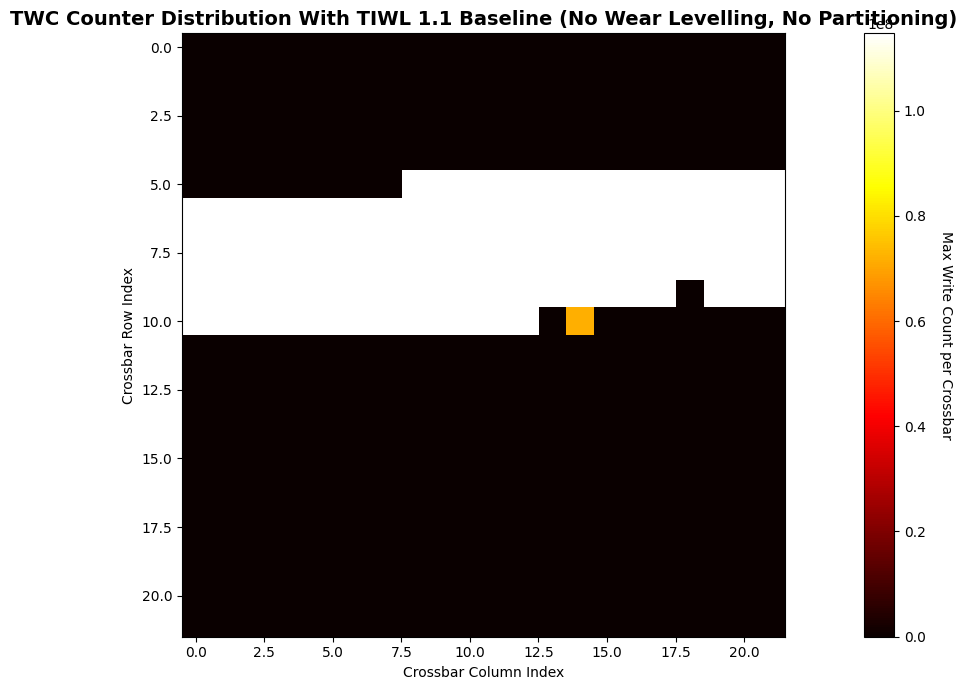

{'Name': '1.1 Baseline (No Wear Levelling, No Partitioning)', 'Accuracy': 95.59, 'Total Accesses': 6999, 'Avg Wear': np.float64(25676000.0), 'Max Wear': np.uint64(114688000), 'Imbalance (Max/Min)': np.float64(114688000.0), 'actual_xbars_used': 236}
--> Successfully logged data for '1.1 Baseline (No Wear Levelling, No Partitioning)' to Google Sheets.

Starting Run: 1.2 (Wear Levelling with Address Remapping)
Crossbar config: (128, 128), 2048 weights per crossbar
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


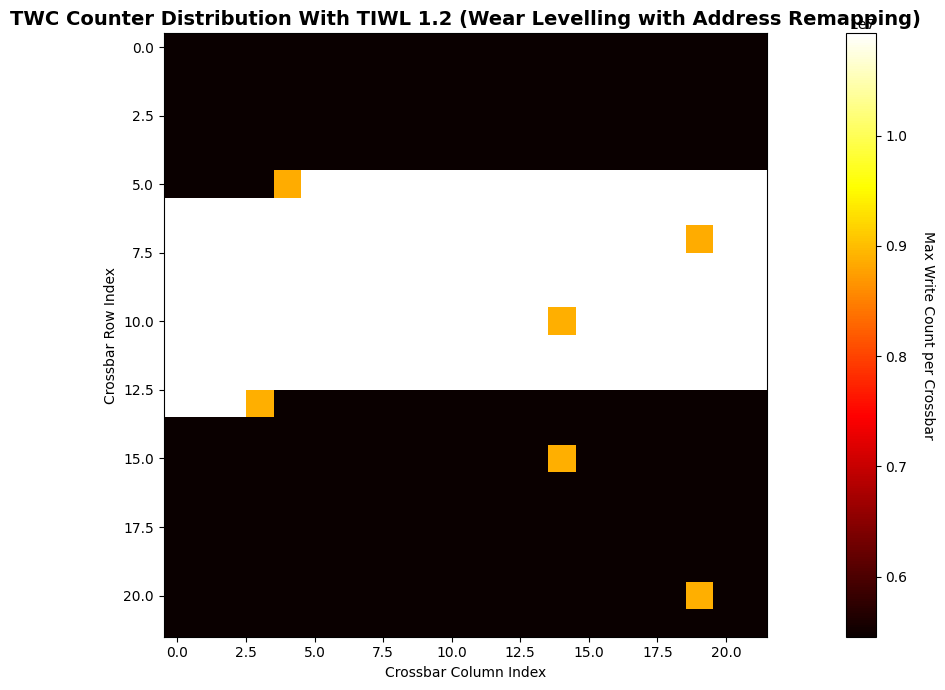

{'Name': '1.2 (Wear Levelling with Address Remapping)', 'Accuracy': 95.12, 'Total Accesses': 6999, 'Avg Wear': np.float64(7336000.0), 'Max Wear': np.uint64(10928128), 'Imbalance (Max/Min)': np.float64(2.0030026358751387), 'actual_xbars_used': 236}
--> Successfully logged data for '1.2 (Wear Levelling with Address Remapping)' to Google Sheets.

Starting Run: 1.3 (Wear Levelling + SLC/MLC Partitioning at 10% slc)
Crossbar config: (128, 128), 2048 weights per crossbar
--> Partitioning Model: 10.0% SLC / 90.0% MLC
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.


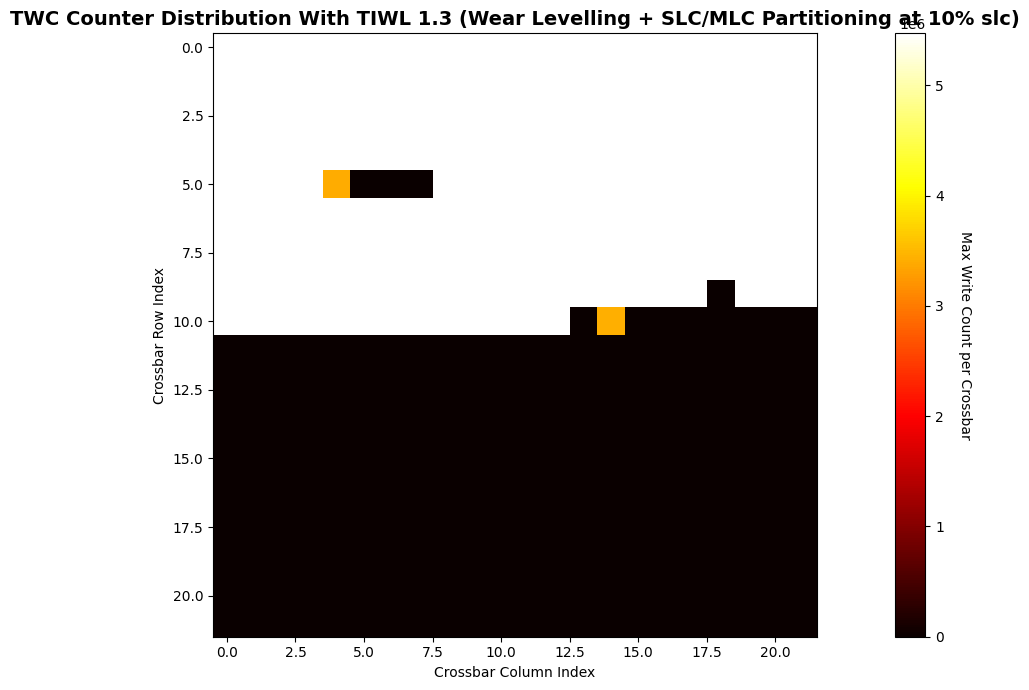

running post capture epochs
Redistributing model: Top 10% to SLC (1-bit), rest to MLC (4-bit)
Mapping complete. SLC Xbars used: 16/51
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.


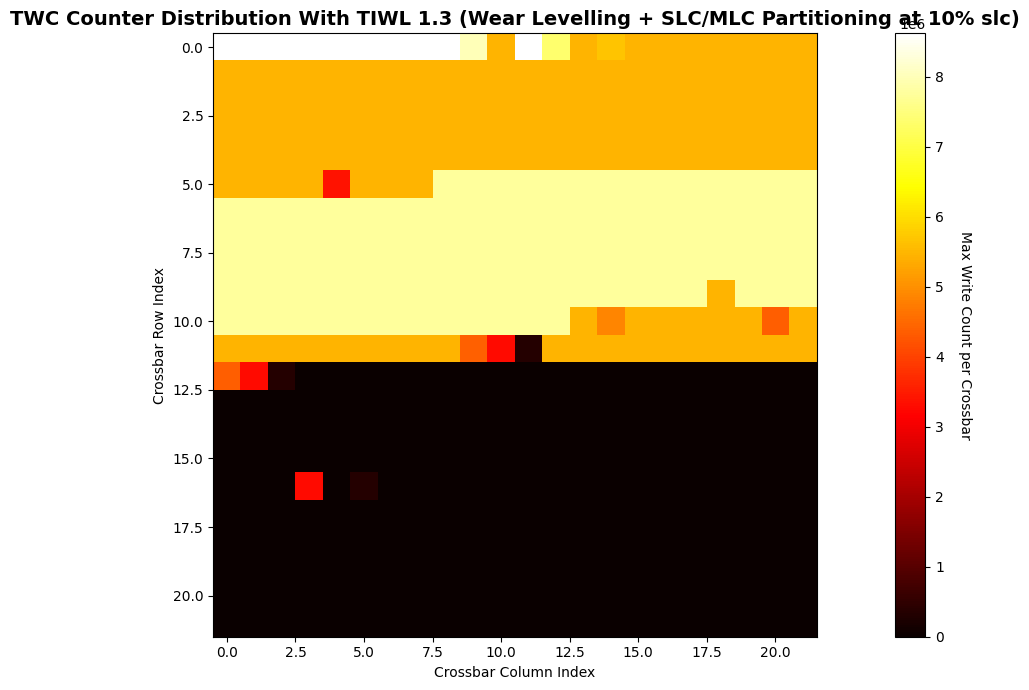

{'Name': '1.3 (Wear Levelling + SLC/MLC Partitioning at 10% slc)', 'Accuracy': 95.21, 'Total Accesses': 6999, 'Avg Wear': np.float64(3400947.25), 'Max Wear': np.uint64(8617984), 'Imbalance (Max/Min)': np.float64(8617984.0), 'actual_xbars_used': 47}
--> Successfully logged data for '1.3 (Wear Levelling + SLC/MLC Partitioning at 10% slc)' to Google Sheets.

Starting Run: 1.4 (Wear Levelling + SLC/MLC Partitioning at 25% slc)
Crossbar config: (128, 128), 2048 weights per crossbar
--> Partitioning Model: 25.0% SLC / 75.0% MLC
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.


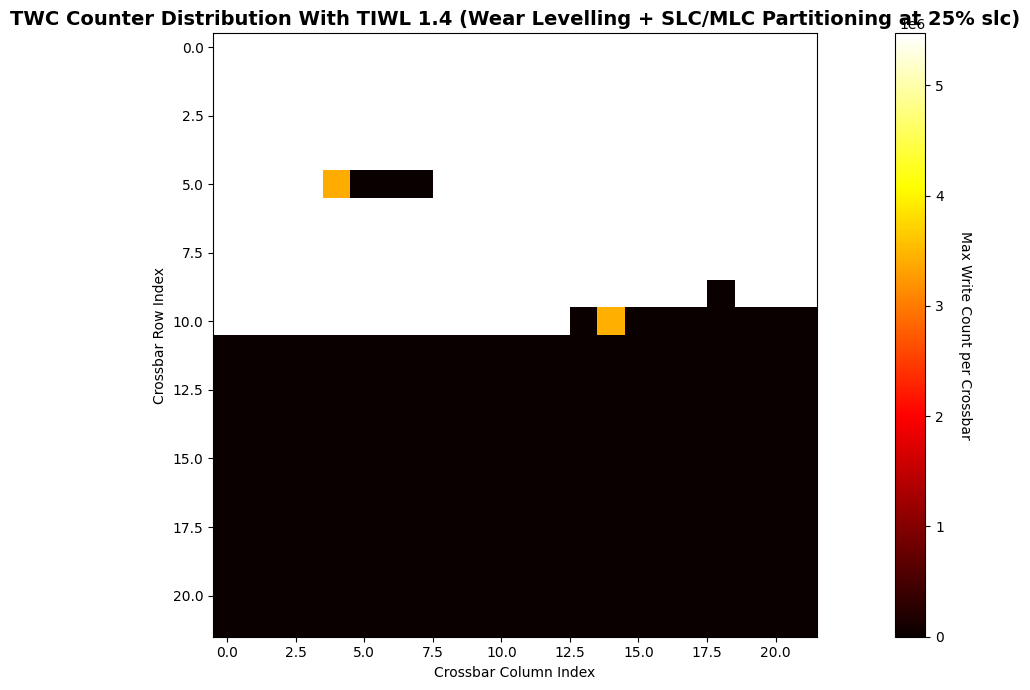

running post capture epochs
Redistributing model: Top 10% to SLC (1-bit), rest to MLC (4-bit)
Mapping complete. SLC Xbars used: 16/51
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.


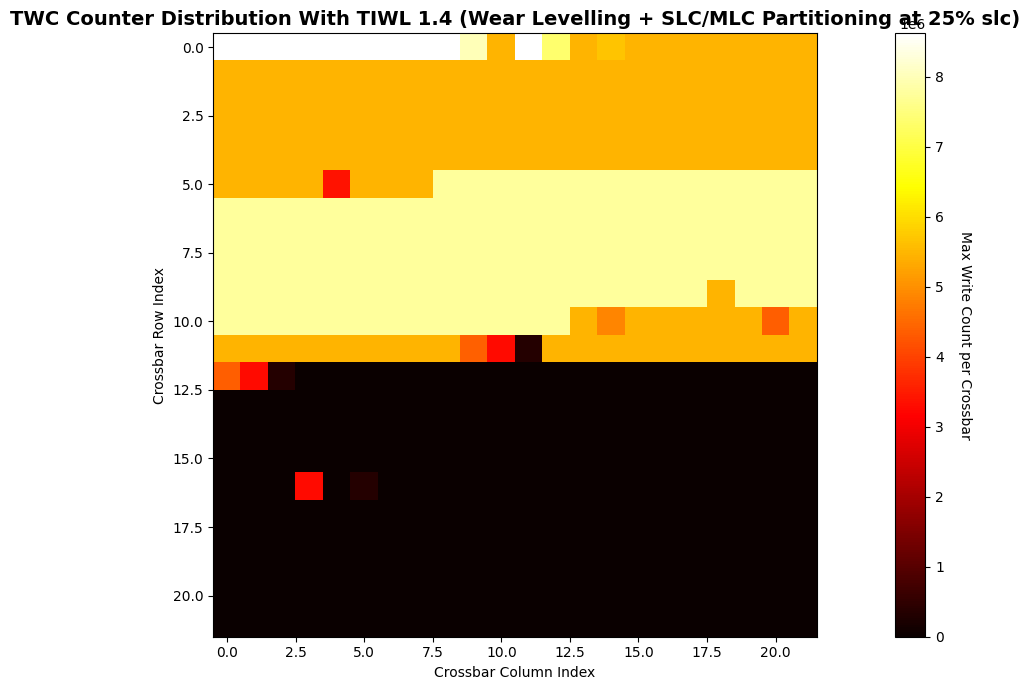

{'Name': '1.4 (Wear Levelling + SLC/MLC Partitioning at 25% slc)', 'Accuracy': 94.91, 'Total Accesses': 6999, 'Avg Wear': np.float64(3400947.25), 'Max Wear': np.uint64(8617984), 'Imbalance (Max/Min)': np.float64(8617984.0), 'actual_xbars_used': 47}
--> Successfully logged data for '1.4 (Wear Levelling + SLC/MLC Partitioning at 25% slc)' to Google Sheets.

Starting Run: 1.5 (Wear Levelling + SLC/MLC Partitioning at 50% slc)
Crossbar config: (128, 128), 2048 weights per crossbar
--> Partitioning Model: 50.0% SLC / 50.0% MLC
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.


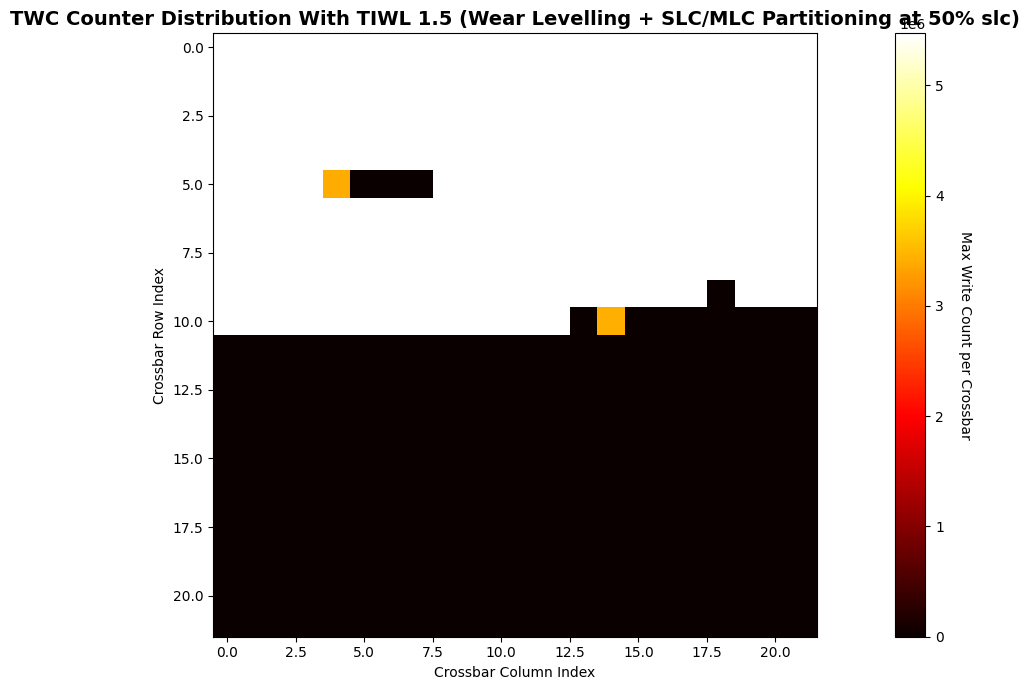

running post capture epochs
Redistributing model: Top 10% to SLC (1-bit), rest to MLC (4-bit)
Mapping complete. SLC Xbars used: 16/51
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.


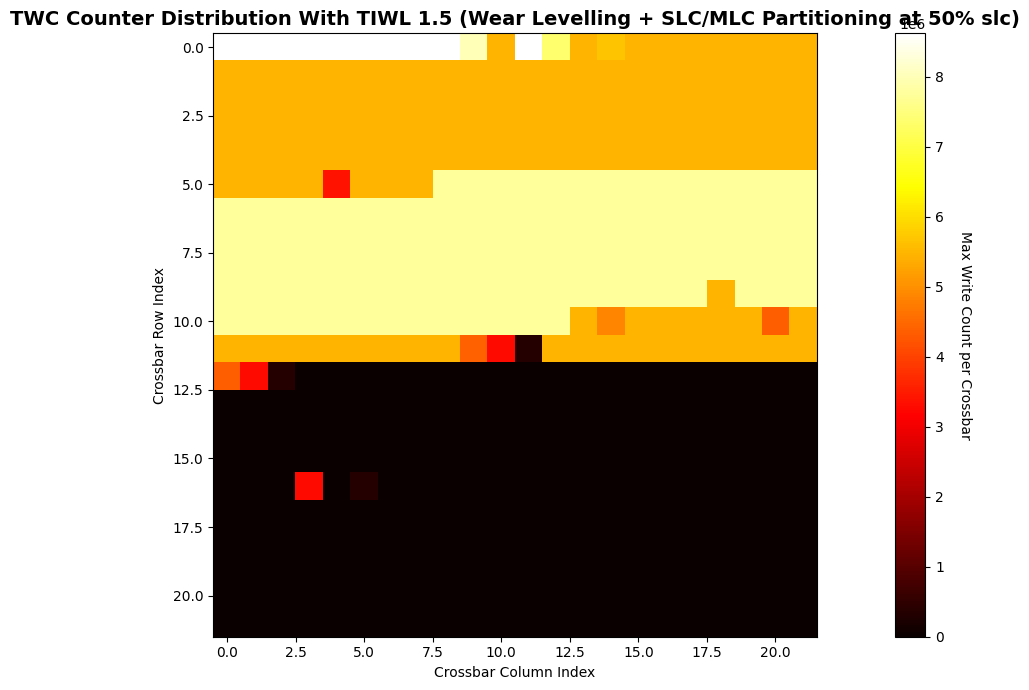

{'Name': '1.5 (Wear Levelling + SLC/MLC Partitioning at 50% slc)', 'Accuracy': 94.83, 'Total Accesses': 6999, 'Avg Wear': np.float64(3400947.25), 'Max Wear': np.uint64(8617984), 'Imbalance (Max/Min)': np.float64(8617984.0), 'actual_xbars_used': 47}
--> Successfully logged data for '1.5 (Wear Levelling + SLC/MLC Partitioning at 50% slc)' to Google Sheets.

Starting Run: 1.6 (Wear Levelling + SLC/MLC Partitioning at 75% slc)
Crossbar config: (128, 128), 2048 weights per crossbar
--> Partitioning Model: 75.0% SLC / 25.0% MLC
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.


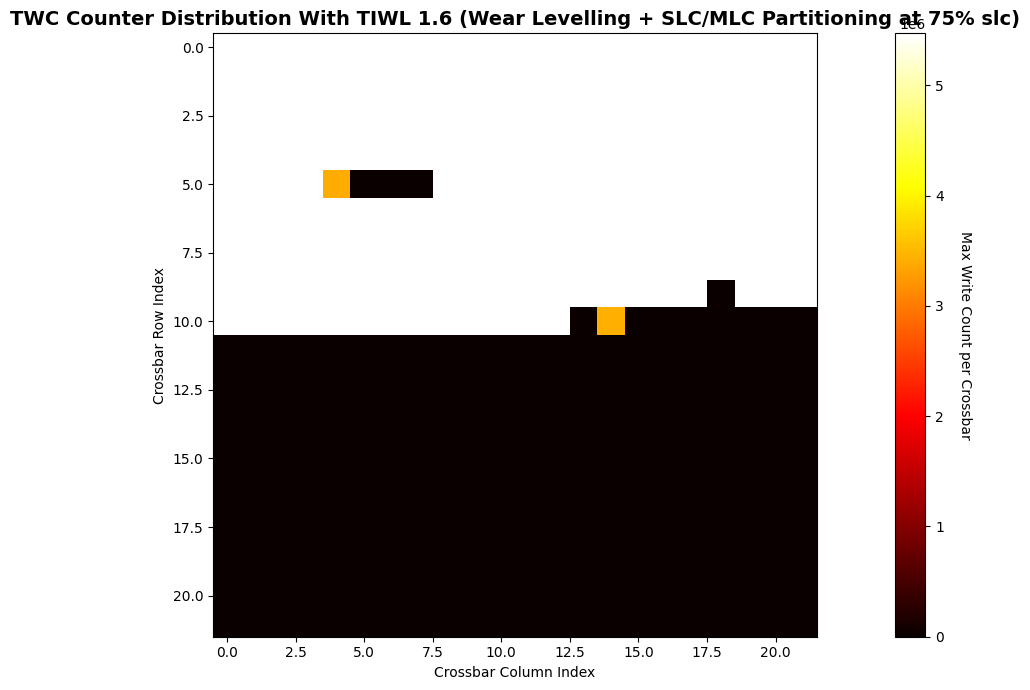

running post capture epochs
Redistributing model: Top 10% to SLC (1-bit), rest to MLC (4-bit)
Mapping complete. SLC Xbars used: 16/51
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.


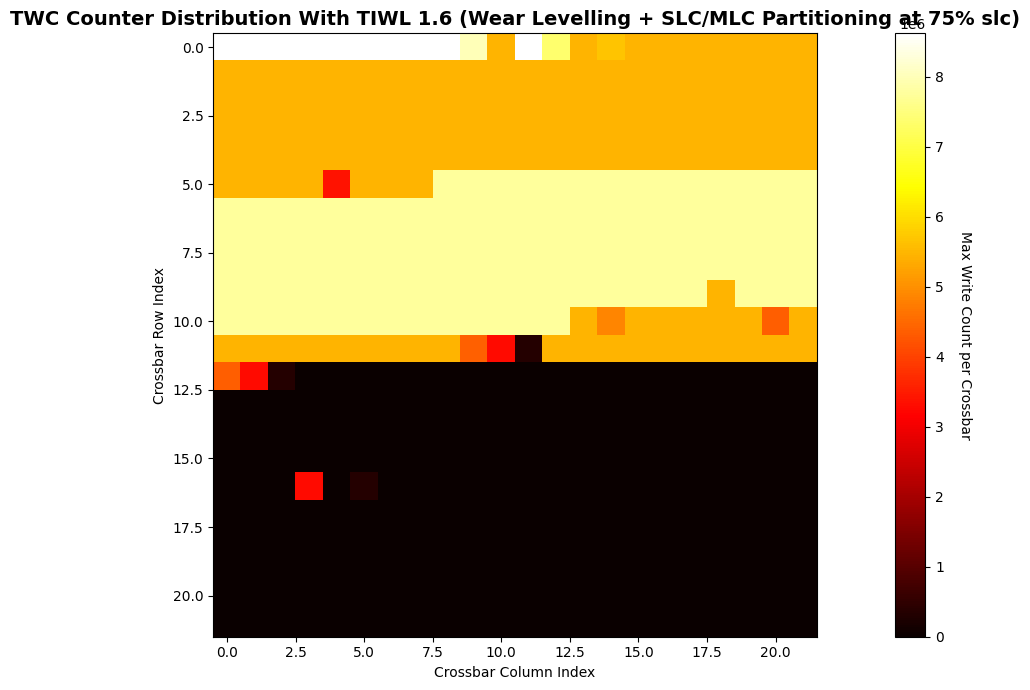

{'Name': '1.6 (Wear Levelling + SLC/MLC Partitioning at 75% slc)', 'Accuracy': 95.1, 'Total Accesses': 6999, 'Avg Wear': np.float64(3400947.25), 'Max Wear': np.uint64(8617984), 'Imbalance (Max/Min)': np.float64(8617984.0), 'actual_xbars_used': 47}
--> Successfully logged data for '1.6 (Wear Levelling + SLC/MLC Partitioning at 75% slc)' to Google Sheets.

Starting Run: 1.7 SLC/MLC Partitioning(only) at 10% slc
Crossbar config: (128, 128), 2048 weights per crossbar
Wear levelling disabled
--> Partitioning Model: 10.0% SLC / 90.0% MLC
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.


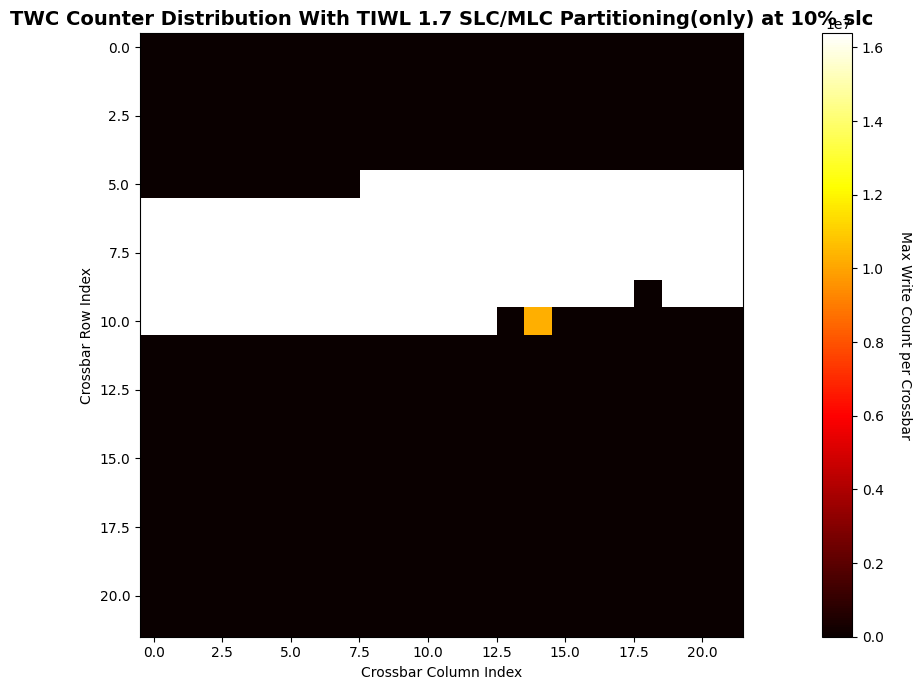

zeroing twc counters
running post capture epochs
Redistributing model: Top 10% to SLC (1-bit), rest to MLC (4-bit)
Mapping complete. SLC Xbars used: 16/51
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.


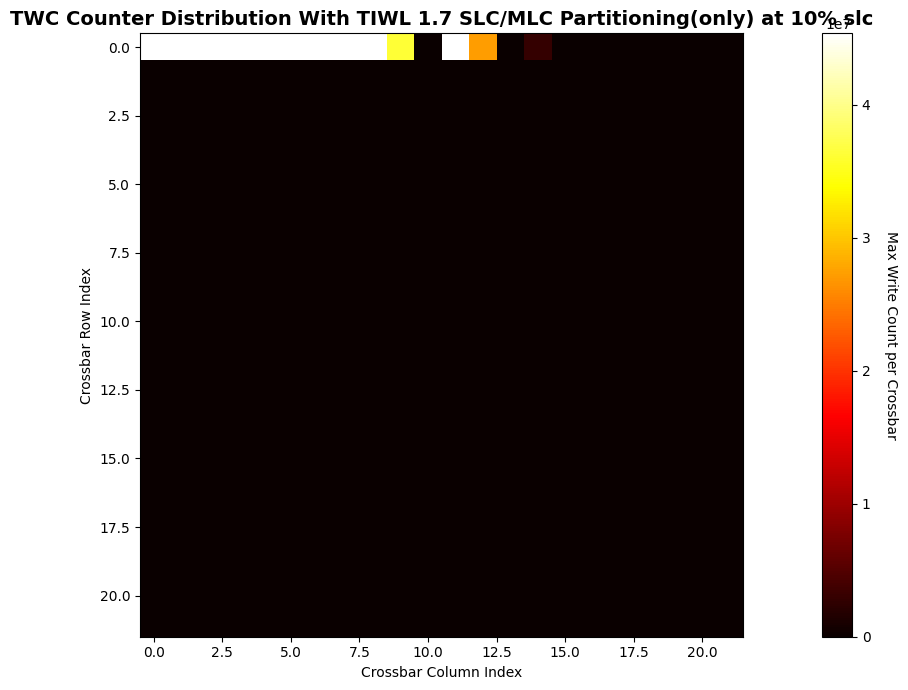

{'Name': '1.7 SLC/MLC Partitioning(only) at 10% slc', 'Accuracy': 94.95, 'Total Accesses': 6999, 'Avg Wear': np.float64(1015250.5), 'Max Wear': np.uint64(45350912), 'Imbalance (Max/Min)': np.float64(45350912.0), 'actual_xbars_used': 47}
--> Successfully logged data for '1.7 SLC/MLC Partitioning(only) at 10% slc' to Google Sheets.


In [20]:
# --- EXPERIMENT CONFIGURATION ---
# DATASET = 'cifar10'
MODEL_NAME = 'custom nn model'
# BATCH_SIZE = 32
# NUM_EPOCHS = 3
# BATCHES_PER_EPOCH = 100
# K_SWAPS = 25
# NUM_CROSSBARS = 100000
# LR = 1e-4
import os
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary

train_loader, test_loader, num_classes = get_dataloaders("mnist")


# Define the 3 instances
configs = [
    {
        "name": "1.1 Baseline (No Wear Levelling, No Partitioning)",
        "model_name": "custom nn model", "epochs": 10, "batches_per_epoch": 100,
        "optimizer": "Adam", "lr": 0.001, "num_crossbars": 512, "k_swaps": 25,
        "epoch_capture_ratio": 1.0, "wear_levelling_enabled": False,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.2 (Wear Levelling with Address Remapping)",
        "model_name": "custom nn model", "epochs": 10, "batches_per_epoch": 100,
        "optimizer": "Adam", "lr": 0.001, "num_crossbars": 512, "k_swaps": 25,
        "epoch_capture_ratio": 1.0,"wear_levelling_enabled": True,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.3 (Wear Levelling + SLC/MLC Partitioning at 10% slc)",
        "model_name": "custom nn model", "epochs": 10, "batches_per_epoch": 100,
        "optimizer": "Adam", "lr": 0.001, "num_crossbars": 512, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.10
    },
    {
        "name": "1.4 (Wear Levelling + SLC/MLC Partitioning at 25% slc)",
        "model_name": "custom nn model", "epochs": 10, "batches_per_epoch": 100,
        "optimizer": "Adam", "lr": 0.001, "num_crossbars": 512, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.25
    },
    {
        "name": "1.5 (Wear Levelling + SLC/MLC Partitioning at 50% slc)",
        "model_name": "custom nn model", "epochs": 10, "batches_per_epoch": 100,
        "optimizer": "Adam", "lr": 0.001, "num_crossbars": 512, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.50
    },
    {
        "name": "1.6 (Wear Levelling + SLC/MLC Partitioning at 75% slc)",
        "model_name": "custom nn model", "epochs": 10, "batches_per_epoch": 100,
        "optimizer": "Adam", "lr": 0.001, "num_crossbars": 512, "k_swaps": 25,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.75
    },
    {
        "name": "1.7 SLC/MLC Partitioning(only) at 10% slc",
        "model_name": "custom nn model", "epochs": 10, "batches_per_epoch": 100,
        "optimizer": "Adam", "lr": 0.001, "num_crossbars": 512, "k_swaps": 25,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": False,
        "partition_enabled": True, "slc_ratio": 0.10
    },
]

(mnist_train_loader, mnist_test_loader, mnist_num_classes) = get_dataloaders('mnist')

# Run the study
results = []
for cfg in configs:
    model_1 = torch.nn.Sequential(
      nn.Flatten(),
      torch.nn.Linear(784, 256),
      torch.nn.ReLU(),
      torch.nn.Linear(256, 128),
      torch.nn.ReLU(),
      torch.nn.Linear(128, 10)
    )
    cfg['dataset_name'] = 'mnist'

    # run simulation
    stats = run_pim_instance(cfg, model_1, mnist_train_loader, mnist_test_loader, mnist_num_classes)
    results.append(stats)
    print(stats)

    # add heatmap plot link
    image_uri = upload_image_to_drive_and_get_formula(drive_service, 'heatmap.png', cfg['name'] + MODEL_NAME)
    results[-1]['xbar_heatmap'] = image_uri

    # 3. PUSH TO GOOGLE SHEETS
    try:
        log_results_to_sheets(worksheet, cfg, results[-1])
    except Exception as e:
        print(f"Failed to log to Google Sheets: {e}")

    # delete the heatmap.png file
    os.remove('heatmap.png')


Starting Run: 1.1 Baseline (No Wear Levelling, No Partitioning)
Crossbar config: (128, 128), 2048 weights per crossbar
Wear levelling disabled
Epoch 1/15 completed.
Epoch 2/15 completed.
Epoch 3/15 completed.
Epoch 4/15 completed.
Epoch 5/15 completed.
Epoch 6/15 completed.
Epoch 7/15 completed.
Epoch 8/15 completed.
Epoch 9/15 completed.
Epoch 10/15 completed.
Epoch 11/15 completed.
Epoch 12/15 completed.
Epoch 13/15 completed.
Epoch 14/15 completed.
Epoch 15/15 completed.


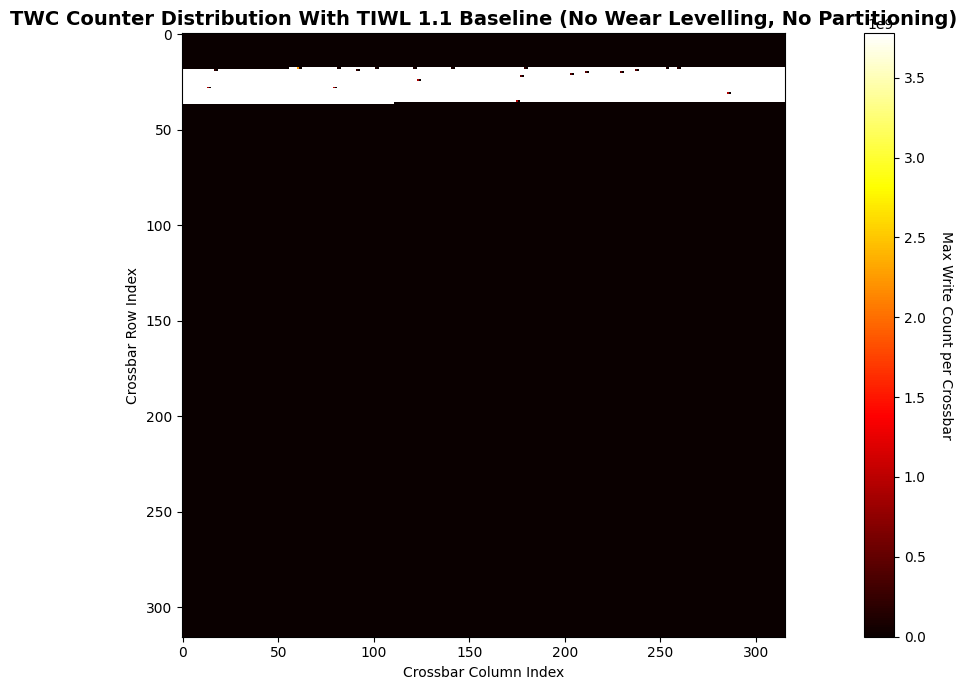

{'Name': '1.1 Baseline (No Wear Levelling, No Partitioning)', 'Accuracy': 83.06, 'Total Accesses': 137063, 'Avg Wear': np.float64(215500793.86112), 'Max Wear': np.uint64(3777626112), 'Imbalance (Max/Min)': np.float64(3777626112.0)}
--> Successfully logged data for '1.1 Baseline (No Wear Levelling, No Partitioning)' to Google Sheets.

Starting Run: 1.2 (Wear Levelling with Address Remapping)
Crossbar config: (128, 128), 2048 weights per crossbar
Epoch 1/15 completed.
Epoch 2/15 completed.
Epoch 3/15 completed.
Epoch 4/15 completed.
Epoch 5/15 completed.
Epoch 6/15 completed.
Epoch 7/15 completed.
Epoch 8/15 completed.
Epoch 9/15 completed.
Epoch 10/15 completed.
Epoch 11/15 completed.
Epoch 12/15 completed.
Epoch 13/15 completed.


In [ ]:
# --- EXPERIMENT CONFIGURATION ---
# DATASET = 'cifar10'
# MODEL_NAME = 'vit_tiny_patch16_224' # Change to 'mobilenetv3_small_050', etc.
# BATCH_SIZE = 32
# NUM_EPOCHS = 3
# BATCHES_PER_EPOCH = 100
# K_SWAPS = 25
# NUM_CROSSBARS = 100000
# LR = 1e-4
import os
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary

LEARNING_RATE = 1e-3
dataset = 'cifar10'
NUM_CROSSBARS = int(1e5)
OPTIMIZER = "AdamW"
MODEL = "resnet18"

train_loader, test_loader, num_classes = get_dataloaders(dataset)

configs = [
    {
        "name": "1.1 Baseline (No Wear Levelling, No Partitioning)",
        "model_name": MODEL, "epochs": 15, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 1.0, "wear_levelling_enabled": False,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.2 (Wear Levelling with Address Remapping)",
        "model_name": MODEL, "epochs": 15, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 1.0,"wear_levelling_enabled": True,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.3 (Wear Levelling + SLC/MLC Partitioning at 10% slc)",
        "model_name": MODEL, "epochs": 15, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.10
    },
    {
        "name": "1.4 (Wear Levelling + SLC/MLC Partitioning at 25% slc)",
        "model_name": MODEL, "epochs": 15, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.25
    },
    {
        "name": "1.5 (Wear Levelling + SLC/MLC Partitioning at 50% slc)",
        "model_name": MODEL, "epochs": 15, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.50
    },
    {
        "name": "1.6 (Wear Levelling + SLC/MLC Partitioning at 75% slc)",
        "model_name": MODEL, "epochs": 15, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.75
    },
    {
        "name": "1.7 SLC/MLC Partitioning(only) at 10% slc",
        "model_name": MODEL, "epochs": 15, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": False,
        "partition_enabled": True, "slc_ratio": 0.10
    },
]

(train_loader, test_loader, num_classes) = get_dataloaders(dataset)

# Run the study
results = []
for cfg in configs:
    model_1 = models.resnet18(weights='DEFAULT')
    cfg['dataset_name'] = dataset

    # run simulation
    stats = run_pim_instance(cfg, model_1, train_loader, test_loader, int(num_classes))
    results.append(stats)
    print(stats)

    # add heatmap plot link
    image_uri = upload_image_to_drive_and_get_formula(drive_service, 'heatmap.png', cfg['name'])
    results[-1]['xbar_heatmap'] = image_uri

    # 3. PUSH TO GOOGLE SHEETS
    try:
        log_results_to_sheets(worksheet, cfg, results[-1])
    except Exception as e:
        print(f"Failed to log to Google Sheets: {e}")

    # delete the heatmap.png file
    os.remove('heatmap.png')

In [ ]:
# --- EXPERIMENT CONFIGURATION ---
# DATASET = 'cifar10'
# MODEL_NAME = 'vit_tiny_patch16_224' # Change to 'mobilenetv3_small_050', etc.
# BATCH_SIZE = 32
# NUM_EPOCHS = 3
# BATCHES_PER_EPOCH = 100
# K_SWAPS = 25
# NUM_CROSSBARS = 100000
# LR = 1e-4
import os
!pip install torchinfo
!pip install timm
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary
import timm

LEARNING_RATE = 1e-4
dataset = 'cifar10'
NUM_CROSSBARS = int(1e4)
OPTIMIZER = "AdamW"
MODEL = "tiny_vit"

train_loader, test_loader, num_classes = get_dataloaders(dataset)

configs = [
    {
        "name": "1.1 Baseline (No Wear Levelling, No Partitioning)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 1.0, "wear_levelling_enabled": False,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.2 (Wear Levelling with Address Remapping)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 1.0,"wear_levelling_enabled": True,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.3 (Wear Levelling + SLC/MLC Partitioning at 10% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.10
    },
    {
        "name": "1.4 (Wear Levelling + SLC/MLC Partitioning at 25% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.25
    },
    {
        "name": "1.5 Baseline (Wear Levelling + SLC/MLC Partitioning at 50% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.50
    },
    {
        "name": "1.6 (Wear Levelling + SLC/MLC Partitioning at 75% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.75
    },
    {
        "name": "1.7 SLC/MLC Partitioning(only) at 10% slc",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": False,
        "partition_enabled": True, "slc_ratio": 0.10
    },
]

(train_loader, test_loader, num_classes) = get_dataloaders(dataset)

# Run the study
results = []
for cfg in configs:
    model_1 = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=10)
    cfg['dataset_name'] = dataset

    # run simulation
    stats = run_pim_instance(cfg, model_1, train_loader, test_loader, int(num_classes))
    results.append(stats)
    print(stats)

    # add heatmap plot link
    image_uri = upload_image_to_drive_and_get_formula(drive_service, 'heatmap.png', cfg['name'] + ' ' + MODEL)
    results[-1]['xbar_heatmap'] = image_uri

    # 3. PUSH TO GOOGLE SHEETS
    try:
        log_results_to_sheets(worksheet, cfg, results[-1])
    except Exception as e:
        print(f"Failed to log to Google Sheets: {e}")

    # delete the heatmap.png file
    os.remove('heatmap.png')

DistilBert/TinyBert

In [ ]:
!pip install transformers datasets


In [ ]:
import os, gc
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
from torch.optim import AdamW

# modified accuracy function for llms
def evaluate_accuracy(model, data_loader, device):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    # Disable gradient calculation for efficiency and to avoid simulator write-hooks
    with torch.no_grad():
        for batch in data_loader:
            # Handle NLP vs Vision batch structures
            if isinstance(batch, dict):
                # For Transformers (TinyBERT/ViT via HuggingFace)
                inputs = {k: v.to(device) for k, v in batch.items() if k != 'label'}
                labels = batch['label'].to(device)
                outputs = model(**inputs)
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs
            else:
                # For standard Vision models (MobileNet/CIFAR-10)
                inputs, labels = batch[0].to(device), batch[1].to(device)
                logits = model(inputs)

            # Calculate predictions
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

LEARNING_RATE = 5e-5
dataset = 'glue/sst2'
NUM_CROSSBARS = int(1.5 * 1e4)
OPTIMIZER = "AdamW"
MODEL = "huawei-noah/TinyBERT_General_4L_312D"
BATCH_SIZE = 16

configs = [
    {
        "name": "1.1 Baseline (No Wear Levelling, No Partitioning)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 1.0, "wear_levelling_enabled": False,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.2 (Wear Levelling with Address Remapping)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 1.0,"wear_levelling_enabled": True,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.3 (Wear Levelling + SLC/MLC Partitioning at 10% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.10
    },
    {
        "name": "1.4 (Wear Levelling + SLC/MLC Partitioning at 25% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.25
    },
    {
        "name": "1.5 (Wear Levelling + SLC/MLC Partitioning at 50% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.50
    },
    {
        "name": "1.6 (Wear Levelling + SLC/MLC Partitioning at 75% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.75
    },
    {
        "name": "1.7 SLC/MLC Partitioning at 10% slc",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": 25,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": False,
        "partition_enabled": True, "slc_ratio": 0.10
    },
]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Run the study
results = []
for config in configs:
    print(f"\n{'='*50}\nStarting Run: {config['name']}\n{'='*50}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL)

    # 2. Prepare Dataset (SST-2 Sentiment Analysis)
    def tokenize_function(examples):
        return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=128)

    train_dataset = load_dataset("glue", "sst2", split='train[:1000]') # Small subset for profiling
    train_tokenized_datasets = train_dataset.map(tokenize_function, batched=True)
    train_tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    train_loader = torch.utils.data.DataLoader(train_tokenized_datasets, batch_size=BATCH_SIZE)

    test_dataset = load_dataset("glue", "sst2", split='validation')
    test_tokenized_datasets = test_dataset.map(tokenize_function, batched=True)
    test_tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    test_loader = torch.utils.data.DataLoader(test_tokenized_datasets, batch_size=BATCH_SIZE)

    model = model.to(device)

    pim_sim = PIMSimulator(
        num_crossbars=config['num_crossbars'],
        wear_levelling_enabled=config['wear_levelling_enabled']
    )
    pim_sim.register_model(model)

    if config['partition_enabled']:
        print(f"--> Partitioning Model: {config['slc_ratio']*100}% SLC / {(1-config['slc_ratio'])*100}% MLC")

    pim_hook = PIMTrainingHook(pim_sim, k_swaps=config['k_swaps'])
    pim_hook.register_hooks(model)
    pim_sim.logger = pim_sim.log_memory_access

    config['dataset_name'] = dataset

    optimizer = AdamW(model.parameters(), lr=config['lr'])
    criterion = nn.CrossEntropyLoss()

    # sanity check
    if not config['wear_levelling_enabled'] or not config['partition_enabled']:
      assert(config['epoch_capture_ratio'] == 1.0)

    # 6. Training Loop
    for epoch in range(int(config['epochs'] * config['epoch_capture_ratio'])):
        model.train()
        for batch_idx, batch in enumerate(train_loader):
            # data, target = data.to(device), target.to(device) # Original line
            optimizer.zero_grad()
            outputs = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            loss = criterion(outputs.logits, batch['label'].to(device))
            loss.backward()
            optimizer.step()

            if batch_idx >= config['batches_per_epoch']:
                break

        print(f"Epoch {epoch+1}/{config['epochs']} completed.")

    if config['partition_enabled']:
      print("running post capture epochs")
      pim_sim.logger = pim_sim.log_memory_access_v2
      pim_sim.redistribute_tensors_by_magnitude(model)

      pim_freeze_manager = PIMFreezeManager(pim_sim)
      pim_freeze_manager.generate_freeze_masks(model)

      for epoch in range(int(config['epochs'] - config['epochs'] * config['epoch_capture_ratio'])):
          model.train()
          for batch_idx, batch in enumerate(train_loader):
              # data, target = data.to(device), target.to(device) # Original line
              optimizer.zero_grad()
              outputs = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
              loss = criterion(outputs.logits, batch['label'].to(device))
              loss.backward()
              # zero out mlc grads
              pim_freeze_manager.apply_freeze(model)
              optimizer.step()

              if batch_idx >= config['batches_per_epoch']:
                  break
          print(f"Epoch {epoch+1}/{config['epochs']} completed.")

    # 7. Evaluate and Collect Stats
    model.to(device)
    test_acc = evaluate_accuracy(model, test_loader, device)

    grid_size = (int(math.sqrt(config['num_crossbars'])), int(math.sqrt(config['num_crossbars'])))
    plot_crossbar_wear_heatmap_singular(pim_sim, config['name'], grid_size, 'heatmap.png')
    stats = {
        "Name": config['name'],
        "Accuracy": test_acc,
        "Total Accesses": pim_sim.access_count,
        "Avg Wear": pim_sim.twc_counters.mean(),
        "Max Wear": pim_sim.twc_counters.max(),
        "Imbalance (Max/Min)": pim_sim.twc_counters.max() / (pim_sim.twc_counters.min() + 1),
    }

    # Free up RAM before the next run
    del model, pim_sim, pim_hook, optimizer
    torch.cuda.empty_cache()
    gc.collect()
    ''' PIM SIM END '''

    results.append(stats)
    print(stats)

    # add heatmap plot link
    image_uri = upload_image_to_drive_and_get_formula(drive_service, 'heatmap.png', config['name'] + ' ' + MODEL)
    results[-1]['xbar_heatmap'] = image_uri

    # 3. PUSH TO GOOGLE SHEETS
    try:
        log_results_to_sheets(worksheet, config, results[-1])
    except Exception as e:
        print(f"Failed to log to Google Sheets: {e}")

    # delete the heatmap.png file
    os.remove('heatmap.png')

In [ ]:
import os, gc
!pip install torchinfo
import torchinfo, torchvision
from torchvision import models
from torchinfo import summary
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
from torch.optim import AdamW

# modified accuracy function for llms
def evaluate_accuracy(model, data_loader, device):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    # Disable gradient calculation for efficiency and to avoid simulator write-hooks
    with torch.no_grad():
        for batch in data_loader:
            # Handle NLP vs Vision batch structures
            if isinstance(batch, dict):
                # For Transformers (TinyBERT/ViT via HuggingFace)
                inputs = {k: v.to(device) for k, v in batch.items() if k != 'label'}
                labels = batch['label'].to(device)
                outputs = model(**inputs)
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs
            else:
                # For standard Vision models (MobileNet/CIFAR-10)
                inputs, labels = batch[0].to(device), batch[1].to(device)
                logits = model(inputs)

            # Calculate predictions
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

LEARNING_RATE = 5e-5
dataset = 'glue/sst2'
NUM_CROSSBARS = int(1.5 * 1e4)
OPTIMIZER = "AdamW"
MODEL = "huawei-noah/TinyBERT_General_4L_312D"
BATCH_SIZE = 16
K_SWAPS = 50

configs = [
    {
        "name": "1.1 Baseline (No Wear Levelling, No Partitioning)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": K_SWAPS,
        "epoch_capture_ratio": 1.0, "wear_levelling_enabled": False,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.2 Baseline (Wear Levelling with Address Remapping)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": K_SWAPS,
        "epoch_capture_ratio": 1.0,"wear_levelling_enabled": True,
        "partition_enabled": False, "slc_ratio": 1.0
    },
    {
        "name": "1.3 Baseline (Wear Levelling + SLC/MLC Partitioning at 10% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": K_SWAPS,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.10
    },
    {
        "name": "1.4 Baseline (Wear Levelling + SLC/MLC Partitioning at 25% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": K_SWAPS,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.25
    },
    {
        "name": "1.5 Baseline (Wear Levelling + SLC/MLC Partitioning at 50% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": K_SWAPS,
        "epoch_capture_ratio": 0.4,"wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.50
    },
    {
        "name": "1.6 Baseline (Wear Levelling + SLC/MLC Partitioning at 75% slc)",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": K_SWAPS,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": True,
        "partition_enabled": True, "slc_ratio": 0.75
    },
    {
        "name": "1.7  SLC/MLC Partitioning at 10% slc",
        "model_name": MODEL, "epochs": 10, "batches_per_epoch": 100,
        "optimizer": OPTIMIZER, "lr": LEARNING_RATE, "num_crossbars": NUM_CROSSBARS, "k_swaps": K_SWAPS,
        "epoch_capture_ratio": 0.4, "wear_levelling_enabled": False,
        "partition_enabled": True, "slc_ratio": 0.10
    },
]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Run the study
results = []
for config in configs:
    print(f"\n{'='*50}\nStarting Run: {config['name']}\n{'='*50}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL)

    # 2. Prepare Dataset (SST-2 Sentiment Analysis)
    def tokenize_function(examples):
        return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=128)

    train_dataset = load_dataset("glue", "sst2", split='train[:1000]') # Small subset for profiling
    train_tokenized_datasets = train_dataset.map(tokenize_function, batched=True)
    train_tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    train_loader = torch.utils.data.DataLoader(train_tokenized_datasets, batch_size=BATCH_SIZE)

    test_dataset = load_dataset("glue", "sst2", split='validation')
    test_tokenized_datasets = test_dataset.map(tokenize_function, batched=True)
    test_tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    test_loader = torch.utils.data.DataLoader(test_tokenized_datasets, batch_size=BATCH_SIZE)

    model = model.to(device)

    pim_sim = PIMSimulator(
        num_crossbars=config['num_crossbars'],
        wear_levelling_enabled=config['wear_levelling_enabled']
    )
    pim_sim.register_model(model)

    if config['partition_enabled']:
        print(f"--> Partitioning Model: {config['slc_ratio']*100}% SLC / {(1-config['slc_ratio'])*100}% MLC")

    pim_hook = PIMTrainingHook(pim_sim, k_swaps=config['k_swaps'])
    pim_hook.register_hooks(model)
    pim_sim.logger = pim_sim.log_memory_access

    config['dataset_name'] = dataset

    optimizer = AdamW(model.parameters(), lr=config['lr'])
    criterion = nn.CrossEntropyLoss()

    # sanity check
    if not config['wear_levelling_enabled'] or not config['partition_enabled']:
      assert(config['epoch_capture_ratio'] == 1.0)

    # 6. Training Loop
    for epoch in range(int(config['epochs'] * config['epoch_capture_ratio'])):
        model.train()
        for batch_idx, batch in enumerate(train_loader):
            # data, target = data.to(device), target.to(device) # Original line
            optimizer.zero_grad()
            outputs = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            loss = criterion(outputs.logits, batch['label'].to(device))
            loss.backward()
            optimizer.step()

            if batch_idx >= config['batches_per_epoch']:
                break

        print(f"Epoch {epoch+1}/{config['epochs']} completed.")

    # genereate a pre mlc disabled heatmap for comparison
    if config['partition_enabled']:
      grid_size = (int(math.sqrt(config['num_crossbars'])), int(math.sqrt(config['num_crossbars'])))
      plot_crossbar_wear_heatmap_singular(pim_sim, config['name'], grid_size, 'heatmap.png')
      image_uri = upload_image_to_drive_and_get_formula(drive_service, 'heatmap.png', config['name'] + ' ' + MODEL + ' (Pre-MLC)')

    if config['partition_enabled']:
      print("running post capture epochs")
      pim_sim.logger = pim_sim.log_memory_access_v2
      pim_sim.redistribute_tensors_by_magnitude(model)

      pim_freeze_manager = PIMFreezeManager(pim_sim)
      pim_freeze_manager.generate_freeze_masks(model)

      for epoch in range(int(config['epochs'] - config['epochs'] * config['epoch_capture_ratio'])):
          model.train()
          for batch_idx, batch in enumerate(train_loader):
              # data, target = data.to(device), target.to(device) # Original line
              optimizer.zero_grad()
              outputs = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
              loss = criterion(outputs.logits, batch['label'].to(device))
              loss.backward()
              # zero out mlc grads
              pim_freeze_manager.apply_freeze(model)
              optimizer.step()

              if batch_idx >= config['batches_per_epoch']:
                  break
          print(f"Epoch {epoch+1}/{config['epochs']} completed.")

    # 7. Evaluate and Collect Stats
    model.to(device)
    test_acc = evaluate_accuracy(model, test_loader, device)

    grid_size = (int(math.sqrt(config['num_crossbars'])), int(math.sqrt(config['num_crossbars'])))
    plot_crossbar_wear_heatmap_singular(pim_sim, config['name'], grid_size, 'heatmap.png')
    stats = {
        "Name": config['name'],
        "Accuracy": test_acc,
        "Total Accesses": pim_sim.access_count,
        "Avg Wear": pim_sim.twc_counters.mean(),
        "Max Wear": pim_sim.twc_counters.max(),
        "Imbalance (Max/Min)": pim_sim.twc_counters.max() / (pim_sim.twc_counters.min() + 1),
    }

    # Free up RAM before the next run
    del model, pim_sim, pim_hook, optimizer
    torch.cuda.empty_cache()
    gc.collect()
    ''' PIM SIM END '''

    results.append(stats)
    print(stats)

    # add heatmap plot link
    image_uri = upload_image_to_drive_and_get_formula(drive_service, 'heatmap.png', config['name'] + ' ' + MODEL)
    results[-1]['xbar_heatmap'] = image_uri

    # 3. PUSH TO GOOGLE SHEETS
    try:
        log_results_to_sheets(worksheet, config, results[-1])
    except Exception as e:
        print(f"Failed to log to Google Sheets: {e}")

    # delete the heatmap.png file
    os.remove('heatmap.png')

LATENCY MEASUREMENT CODE (NOT USEFULE)

In [ ]:
import os
import torch
import torch.nn as nn
import timm # Required for some models like ViT, though ResNet is from torchvision
from torchvision import datasets, transforms, models # Ensure models is imported
import time

# Ensure device is set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_dataloaders(dataset_name='cifar10', batch_size=32):
    if dataset_name.lower() == 'cifar10':
        transform = transforms.Compose([
          transforms.Resize((224, 224)), # ResNet expects 224x224 input
          transforms.ToTensor(),
          transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

        train_ds = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        num_classes = 10
    else:
        raise ValueError(f"Dataset {dataset_name} not supported yet.")

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, num_classes

# --- Latency Measurement for ResNet18 on CIFAR-10 ---

# 1. Configuration
NUM_ITERATIONS = 100
BATCH_SIZE = 32 # Keep a reasonable batch size for GPU
LEARNING_RATE = 1e-3

# 2. Prepare Data Loaders
train_loader, _, _ = get_dataloaders(dataset_name='cifar10', batch_size=BATCH_SIZE)

# 3. Initialize Model (ResNet18) and move to device
model = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, 10) # Adjust output layer for CIFAR-10
model.to(device)
model.train() # Set to training mode

# 4. Define Optimizer and Loss Function
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# Get one batch for warm-up and timing
# It's important to use actual data for realistic timing
data_iter = iter(train_loader)
inputs, targets = next(data_iter)
inputs, targets = inputs.to(device), targets.to(device)

# 5. Warm-up (Standard practice in PIM/GPU research to clear initial overhead)
print("Performing warm-up...")
for _ in range(10):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
if device.type == 'cuda':
    torch.cuda.synchronize() # Wait for GPU to finish

# 6. Actual Latency Measurement
print(f"Measuring latency for {NUM_ITERATIONS} iterations...")
total_latency = 0.0

for i in range(NUM_ITERATIONS):
    # Get a new batch for each iteration if possible, or reuse for consistent measurement
    try:
        inputs, targets = next(data_iter)
    except StopIteration:
        # Reset the data iterator if it runs out of batches
        data_iter = iter(train_loader)
        inputs, targets = next(data_iter)

    inputs, targets = inputs.to(device), targets.to(device)

    start_event = torch.cuda.Event(enable_timing=True) if device.type == 'cuda' else None
    end_event = torch.cuda.Event(enable_timing=True) if device.type == 'cuda' else None
    start_time = time.time() if device.type == 'cpu' else None

    if start_event: start_event.record()

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    if end_event: end_event.record()

    if device.type == 'cuda':
        torch.cuda.synchronize() # Wait for GPU to finish
        iteration_latency = start_event.elapsed_time(end_event) # Result in milliseconds
    else:
        iteration_latency = (time.time() - start_time) * 1000 # Result in milliseconds

    total_latency += iteration_latency

average_latency = total_latency / NUM_ITERATIONS

print(f"\nAverage end-to-end iteration latency over {NUM_ITERATIONS} iterations: {average_latency:.4f} ms")
